**Dicionário das variáveis**

* **Row_ID** : Identificador único de cada linha
* **Order_ID** : Identificador único do pedido
* **Order_Date** : Data do pedido
* **Ship_Date** : Data de envio do pedido
* **Ship_Mode** : Modalidade de envio escolhida
* **Customer_ID** : Identificador único do cliente
* **Customer_Name** : Nome do cliente
* **Segment** : Segmento de mercado do cliente
* **Country** : País do cliente
* **City** : Cidade do cliente
* **State** : Estado do cliente
* **Postal_Code** :  Código postal
* **Region** : Região do cliente
* **Product_ID** : Identificador do produto
* **Category** : Categoria do produto
* **Sub_Category** : Subcategoria do produto
* **Product Name** : Nome do produto
* **Sales** : Valor de venda
* **Quantity** : Quantidade vendida
* **Discount** : Desconto aplicado
* **Profit** : Lucro ou prejuízo da venda

In [1]:
# importar os pacotes necessarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Mounted at /content/drive


In [4]:
column_names = [
    'Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode' , 'Customer_ID',
    'Customer_Name', 'Segment', 'Country', 'City', 'State',
    'Postal_Code', 'Region', 'Product_ID', 'Category',
    'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
    'Profit'
]
df = pd.read_csv(f'{path}/01_supermercados.csv', names=column_names, header=0,encoding='latin1')
df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [5]:
df["Order_Date_Formatado"] = pd.to_datetime(df['Order_Date'])

In [6]:
df['Year'] = df['Order_Date_Formatado'].dt.year

In [7]:
df_clean = df.copy()

# Limpando a coluna PROFIT
Q1_profit = df_clean['Profit'].quantile(0.25)
Q3_profit = df_clean['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

limite_inf_profit = Q1_profit - 1.5 * IQR_profit
limite_sup_profit = Q3_profit + 1.5 * IQR_profit

# Aqui deixamos o limite inferior ser negativo normalmente
df_clean = df_clean[(df_clean['Profit'] >= limite_inf_profit) & (df_clean['Profit'] <= limite_sup_profit)]


# Limpando a coluna SALES (Vendas)
Q1_sales = df_clean['Sales'].quantile(0.25)
Q3_sales = df_clean['Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

# Aqui usamos o max(0, ...) para garantir que o limite de vendas não caia abaixo de zero
limite_inf_sales = max(0, Q1_sales - 1.5 * IQR_sales)
limite_sup_sales = Q3_sales + 1.5 * IQR_sales

df_clean = df_clean[(df_clean['Sales'] >= limite_inf_sales) & (df_clean['Sales'] <= limite_sup_sales)]

##Analisando as Regiões com baixa Rentabilidade ao Longo dos Anos



### Analisando as regiões com menos Rentabilidade ao Longo dos Anos

In [108]:
#. Filtrando a Rentabilidade por Região dos 4 anos
rentabilidade_regiao = df_clean.groupby('Region').Profit.mean()

#. Filtrando a Rentabilidade por Região e Ano
rentabilidade_regiao_anual = pd.crosstab(df_clean["Region"], df_clean["Year"], aggfunc = 'sum', values = df_clean["Profit"])

#. Exibindo a Rentabilidade considerando os 4 anos de DataSet
print(f"Rentabilidade Geral:\n{rentabilidade_regiao.sort_values(ascending=True)}\n\n")

#. Exibindo a Rentabilidade por Região em 2014
print(f"Rentabilidade Anual 2014:\n{rentabilidade_regiao_anual[2014].sort_values(ascending=True)}\n\n")

#. Exibindo a Rentabilidade por Região em 2015
print(f"Rentabilidade Anual 2015:\n{rentabilidade_regiao_anual[2015].sort_values(ascending=True)}\n\n")

#. Exibindo a Rentabilidade por Região em 2016
print(f"Rentabilidade Anual 2016:\n{rentabilidade_regiao_anual[2016].sort_values(ascending=True)}\n\n")

#. Exibindo a Rentabilidade por Região em 2017
print(f"Rentabilidade Anual 2017:\n{rentabilidade_regiao_anual[2017].sort_values(ascending=True)}\n\n")

Rentabilidade Geral:
Region
Central     6.844666
East       10.154005
South      10.482072
West       12.482127
Name: Profit, dtype: float64


Rentabilidade Anual 2014:
Region
Central    1704.5467
South      2934.2855
East       3771.3376
West       6067.2652
Name: 2014, dtype: float64


Rentabilidade Anual 2015:
Region
Central    2246.8676
South      3213.2461
East       4746.3900
West       6105.4350
Name: 2015, dtype: float64


Rentabilidade Anual 2016:
Region
South      3022.0357
Central    3465.8611
East       5792.8961
West       6506.3360
Name: 2016, dtype: float64


Rentabilidade Anual 2017:
Region
South       3398.4370
Central     3979.0928
East        6840.1681
West       10641.4805
Name: 2017, dtype: float64




- Podemos ver que, mesmo tirarando os outliers, as regiões Central e South continuam sendo as piores regiões, em questão de rentabilidade.

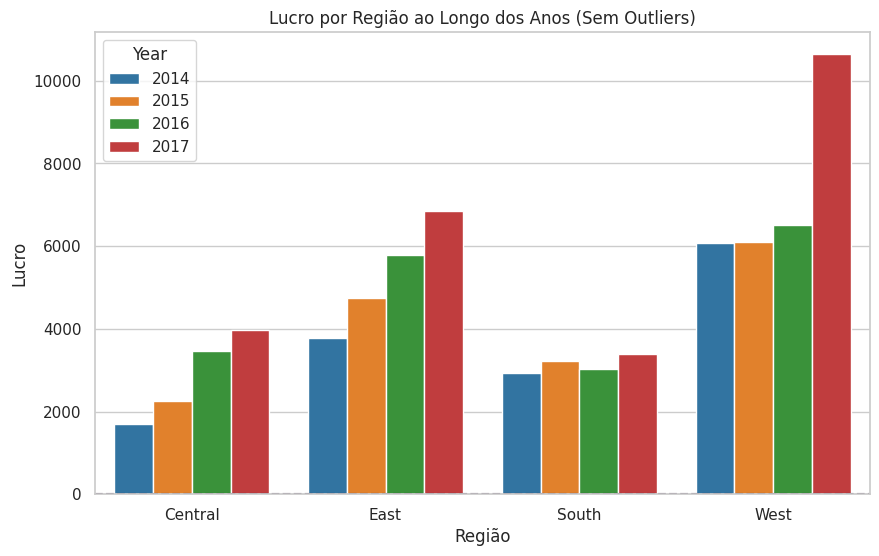

In [107]:
#. Agrupando dados para visualização em gráfico
dados_rendimento_regiao = df_clean.groupby(['Year', 'Region'])['Profit'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(data=dados_rendimento_regiao, x='Region', y='Profit', hue='Year', palette='tab10')

plt.title('Lucro por Região ao Longo dos Anos (Sem Outliers)')
plt.xlabel('Região')
plt.ylabel('Lucro')

plt.axhline(0, linestyle='--')

plt.show()

### Analisando a quantidade de Dados das Regiões ao Longo dos Anos

In [143]:
#. Descobrindo a quantidade de dados para as regiões menos rentáveis do DataSet ao longo dos anos
print(f"Quantidade de dados para a região Central do ano de 2014:\n{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].shape}\n")
print(f"Quantidade de dados para a região South do ano de 2014:\n{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')].shape}\n")

print(f"Quantidade de dados para a região Central do ano de 2015:\n{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].shape}\n")
print(f"Quantidade de dados para a região South do ano de 2015:\n{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].shape}\n")

print(f"Quantidade de dados para a região South do ano de 2016:\n{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')].shape}\n")
print(f"Quantidade de dados para a região Central do ano de 2016:\n{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')].shape}\n")

print(f"Quantidade de dados para a região South do ano de 2017:\n{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')].shape}\n")
print(f"Quantidade de dados para a região Central do ano de 2017:\n{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].shape}\n")

Quantidade de dados para a região Central do ano de 2014:
(334, 23)

Quantidade de dados para a região South do ano de 2014:
(259, 23)

Quantidade de dados para a região Central do ano de 2015:
(329, 23)

Quantidade de dados para a região South do ano de 2015:
(257, 23)

Quantidade de dados para a região South do ano de 2016:
(304, 23)

Quantidade de dados para a região Central do ano de 2016:
(441, 23)

Quantidade de dados para a região South do ano de 2017:
(379, 23)

Quantidade de dados para a região Central do ano de 2017:
(561, 23)



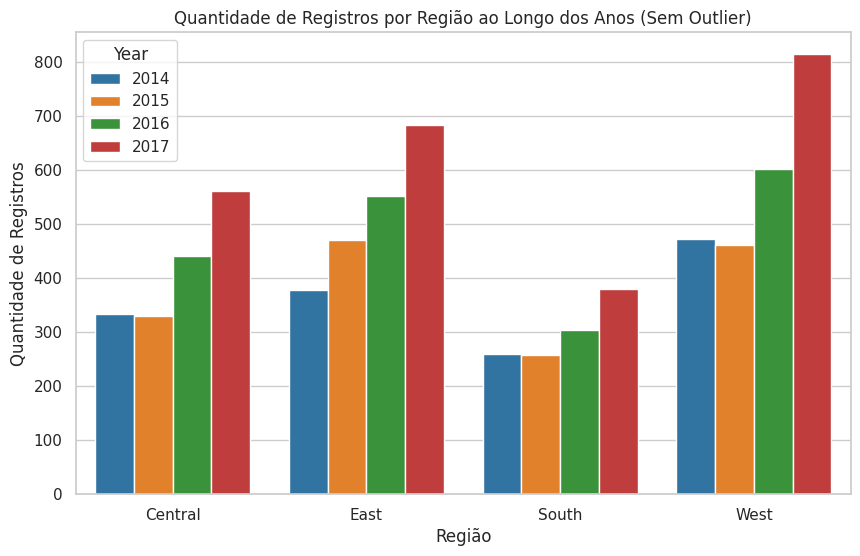

In [115]:
#. Agrupando dados para visualização em gráfico
dados_qtd_regiao = df_clean.groupby(['Year', 'Region']).size().reset_index(name='Quantidade')

plt.figure(figsize=(10,6))

sns.barplot(data=dados_qtd_regiao, x='Region', y='Quantidade', hue='Year', palette='tab10')

plt.title('Quantidade de Registros por Região ao Longo dos Anos (Sem Outlier)')
plt.xlabel('Região')
plt.ylabel('Quantidade de Registros')

plt.show()

- Podemos ver que a quantidade de dados para as regiões menos rentáveis ainda são baixas, mesmo sem os outliers, o que significa que o fato delas estarem com baixa rentabilidade se dá por outros motivos

### Analisando os Dados Estatísticos das Regiões ao Longo dos Anos

In [116]:
#. Exibindo os dados estatísticos da Região com a menor rentabilidade do Ano de 2014
df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,334.000000,334.000000,334.000000,334.000000,334.000000,334.000000,334,334.0
mean,5327.616766,66547.547904,41.792538,3.422156,0.257305,5.103433,2014-08-08 03:05:23.353293312,2014.0
min,47.000000,46203.000000,0.876000,1.000000,0.000000,-38.111400,2014-01-03 00:00:00,2014.0
25%,2893.250000,60076.000000,9.284000,2.000000,0.000000,-3.430125,2014-05-19 06:00:00,2014.0
50%,5261.500000,68104.000000,20.760000,3.000000,0.200000,4.065500,2014-09-07 00:00:00,2014.0
75%,8022.750000,77070.000000,53.074000,4.000000,0.200000,10.696800,2014-11-13 12:00:00,2014.0
max,9905.000000,79907.000000,227.976000,14.000000,0.800000,69.177600,2014-12-31 00:00:00,2014.0
std,2891.467752,11208.227793,49.839561,1.950957,0.274557,16.974235,NaN,0.0


- Pela descrição dos dados podemos ver que essa região já não é tão impactada por outliers. Porém, que ainda apresenta valores distantes, o que pode indicar um comportamento normal dessa região.

In [117]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')]['Category'].value_counts()}\n")

Category
Furniture          0.389545
Office Supplies    0.252209
Technology         0.146341
Name: Discount, dtype: float64

Category
Furniture          0.6
Office Supplies    0.8
Technology         0.2
Name: Discount, dtype: float64

Discount
0.20    143
0.00    106
0.80     50
0.60     24
0.30      7
0.32      2
0.10      2
Name: count, dtype: int64

74

-909.6957000000001

1704.5467

Category
Furniture          -197.9932
Office Supplies    1460.6049
Technology          441.9350
Name: Profit, dtype: float64

Category
Office Supplies    249
Furniture           44
Technology          41
Name: count, dtype: int64



- Podemos ver que a quantidade de descontos altos diminuiu. Porém, ainda deram um prejuízo e também vemos que a categoria Furniture é a que tem a maior média de descontos dessa região

/tmp/ipykernel_12466/3894005415.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.boxplot(data=df_clean[(df['Year'] == 2014) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')
/tmp/ipykernel_12466/3894005415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df['Year'] == 2014) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')


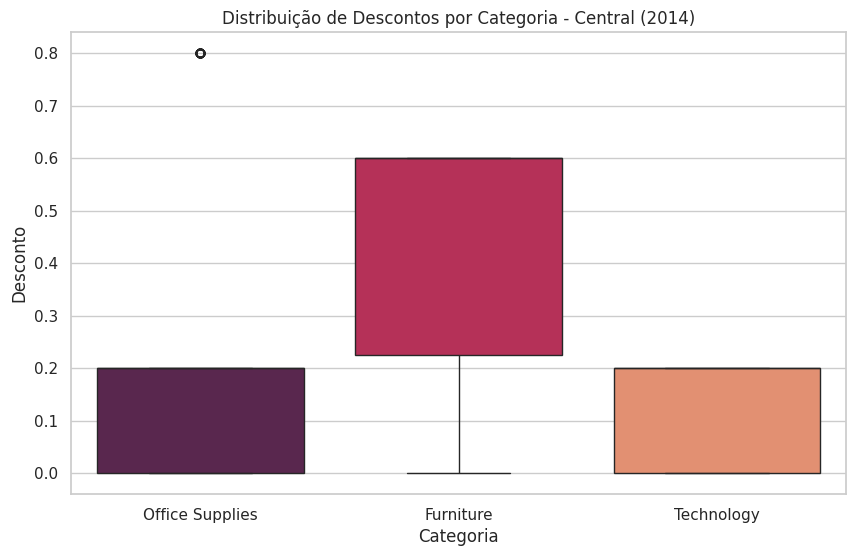

In [119]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df['Year'] == 2014) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - Central (2014)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [141]:
#. Exibindo os dados estatísticos da segunda região com a menor rentabilidade do Ano de 2014
df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,259.000000,259.000000,259.000000,259.000000,259.000000,259.000000,259,259.0
mean,4806.370656,34553.702703,49.898402,3.444015,0.126255,11.329288,2014-07-10 06:51:25.714285824,2014.0
min,184.000000,22153.000000,1.167000,1.000000,0.000000,-39.456500,2014-01-06 00:00:00,2014.0
25%,2530.500000,28205.000000,11.916000,2.000000,0.000000,2.678200,2014-03-27 00:00:00,2014.0
50%,4422.000000,32712.000000,24.560000,3.000000,0.000000,7.021800,2014-07-26 00:00:00,2014.0
75%,7430.500000,37769.000000,66.064000,4.500000,0.200000,15.415800,2014-10-21 12:00:00,2014.0
max,9990.000000,72701.000000,223.960000,13.000000,0.700000,65.978000,2014-12-30 00:00:00,2014.0
std,2885.832049,12370.802600,54.672781,1.988278,0.180024,16.023970,NaN,0.0


- Pela descrição dos dados podemos ver que essa região também já não é mais altamente impactada por outliers. Porém, ainda possui valores distantes como por exemplo o máximo. Entretanto, não é tão discrepante, o que também pode indicar um comportamento da região

In [144]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')]['Category'].value_counts()}\n")

Category
Furniture          0.100000
Office Supplies    0.144444
Technology         0.050000
Name: Discount, dtype: float64

Category
Furniture          0.2
Office Supplies    0.7
Technology         0.2
Name: Discount, dtype: float64

Discount
0.0    138
0.2    104
0.7     17
Name: count, dtype: int64

17

-189.79739999999998

2934.2855

Category
Furniture           497.1062
Office Supplies    1653.9177
Technology          783.2616
Name: Profit, dtype: float64

Category
Office Supplies    189
Furniture           38
Technology          32
Name: count, dtype: int64



- Aqui podemos ver uma grande diferença no comportamento dos dados sem outliers. Agora não são tantas vendas com alto descontos e o prejuízo causados por eles não é tão grande assim.

/tmp/ipykernel_12466/133671915.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')


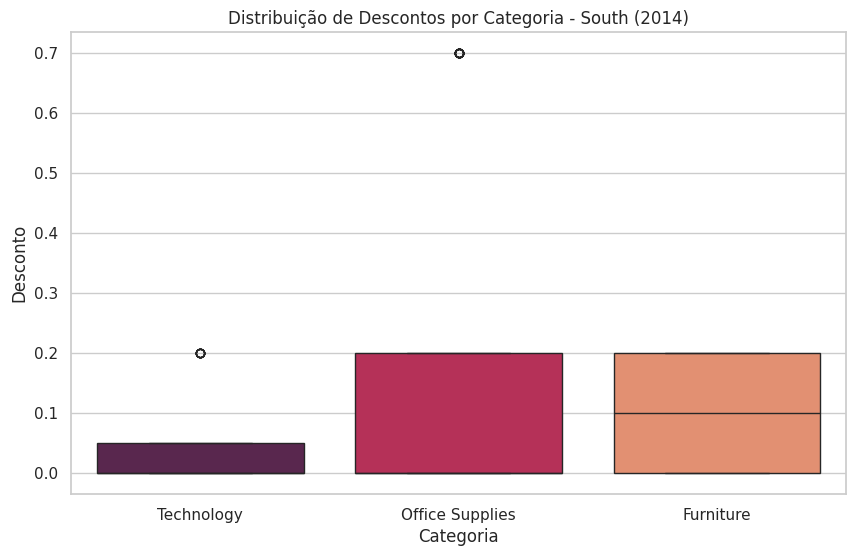

In [145]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - South (2014)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Após essa análise. Podemos ver como vendas com alto descontos prejudicam o faturamento da empresa. Por mais que as duas sejam as regiões com menos rentabilidade. A que foi pior escolheu o lado dos altos descontos enquanto a "melhor" escolheu o lado dos descontos baixos e equilibrados. Vamos ver se esse comportamento se repete para os demais anos.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


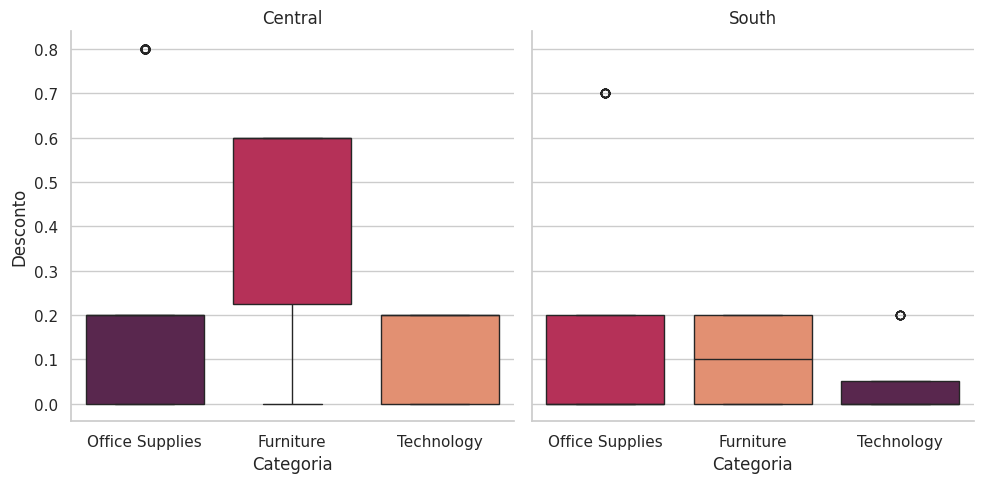

In [146]:
dados = df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

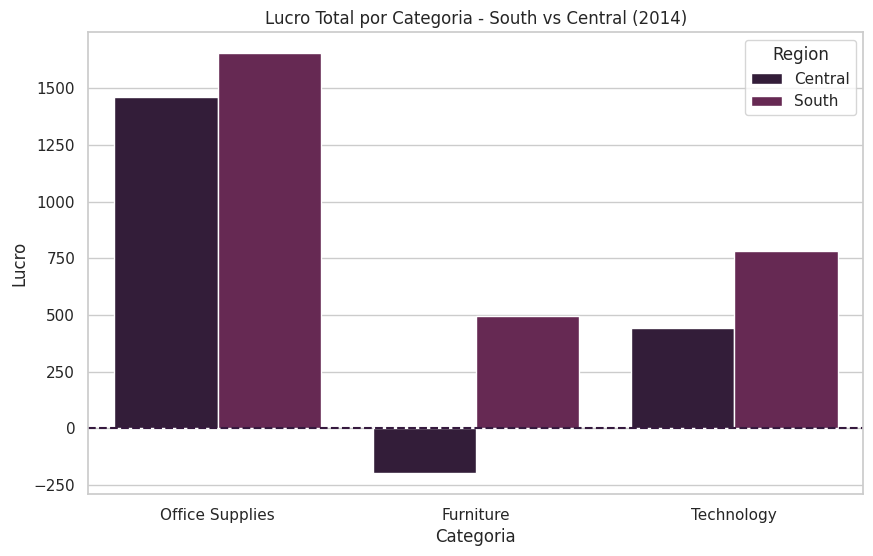

In [147]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'].isin(['Central', 'South']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2014)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

In [129]:
df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257,257.0
mean,5405.287938,33492.439689,53.866549,3.603113,0.156809,12.502903,2015-08-10 19:47:51.595330816,2015.0
min,5.000000,22153.000000,1.780000,1.000000,0.000000,-33.841800,2015-01-04 00:00:00,2015.0
25%,3530.000000,28540.000000,11.952000,2.000000,0.000000,1.638000,2015-06-08 00:00:00,2015.0
50%,5836.000000,33024.000000,33.020000,3.000000,0.200000,7.596000,2015-09-04 00:00:00,2015.0
75%,7754.000000,37130.000000,75.000000,5.000000,0.200000,16.980000,2015-11-08 00:00:00,2015.0
max,9981.000000,72701.000000,226.200000,14.000000,0.700000,69.705000,2015-12-31 00:00:00,2015.0
std,2738.348712,9441.344900,53.717014,2.209282,0.207200,18.249717,NaN,0.0


- Novamente, podemos ver que a região não sofre mais com outliers. Porém, possui valores distantes, mínimo e máximo. Entretanto, isso aparenta ser uma distância saudável e relativamente comum no contexto da base.

In [130]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')]['Category'].value_counts()}\n")

Category
Furniture          0.115556
Office Supplies    0.173034
Technology         0.126471
Name: Discount, dtype: float64

Category
Furniture          0.2
Office Supplies    0.7
Technology         0.5
Name: Discount, dtype: float64

Discount
0.0    122
0.2    108
0.7     26
0.5      1
Name: count, dtype: int64

26

-187.0351

3213.2461000000003

Category
Furniture           608.9364
Office Supplies    2105.3814
Technology          498.9283
Name: Profit, dtype: float64

Category
Office Supplies    178
Furniture           45
Technology          34
Name: count, dtype: int64



- Podemos observar que não foram realizadas muitas vendas com altos descontos, e o prejuízo resultante não foi tão alto. Porém, o maior desconto médio foi aplicado para a categoria Office Supplies, que é uma categoria rentável para empresa. Então podemos imaginar que essa região ficou em uma colocação baixa por conta de ter "errado" a sua distribuição dos descontos.

/tmp/ipykernel_12466/1223293534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')


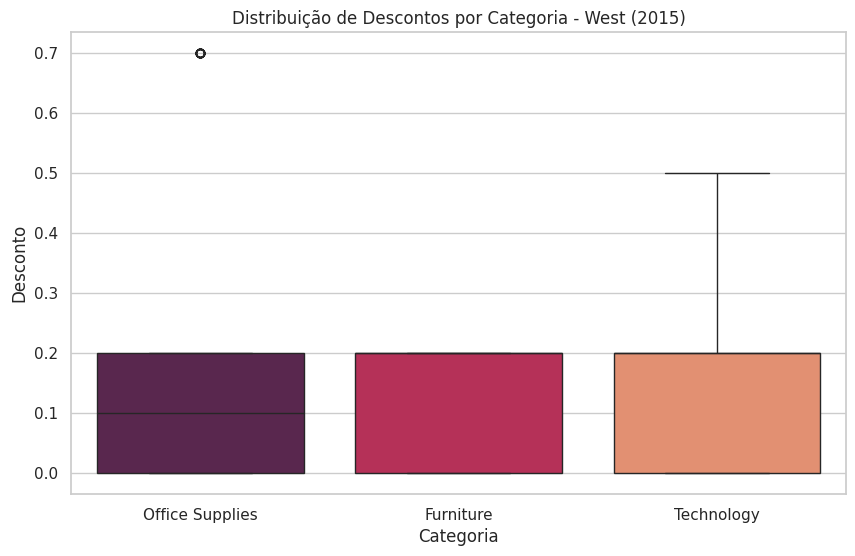

In [132]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - West (2015)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Também é possível observar que 25% das vendas da categoria de Technology receberam descontos maiores que 20% e menores que 50% e, por conta de ser uma categoria de produtos com um alto valor agragado, esses descontos "pequenos" geram um impacto significativo no lucro, o que pode ser o motivo dessa região ter ficado em uma baixa colocação.

In [133]:
df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329,329.0
mean,5007.574468,64681.054711,52.768337,3.465046,0.238298,6.829385,2015-08-04 16:51:03.829787136,2015.0
min,16.000000,46060.000000,0.984000,1.000000,0.000000,-33.641400,2015-01-03 00:00:00,2015.0
25%,2526.000000,53142.000000,10.368000,2.000000,0.000000,-2.569800,2015-04-30 00:00:00,2015.0
50%,4959.000000,63116.000000,25.900000,3.000000,0.200000,4.756000,2015-08-23 00:00:00,2015.0
75%,7724.000000,77041.000000,76.640000,4.000000,0.200000,13.438600,2015-11-12 00:00:00,2015.0
max,9962.000000,79907.000000,223.888000,11.000000,0.800000,69.965000,2015-12-31 00:00:00,2015.0
std,2941.083247,12081.804283,58.310245,2.055516,0.272172,17.852003,NaN,0.0


- Mais uma vez, percebemos que o impacto dos outliers já não são tão perceptíveis embora ainda tenha um certo distanciamento dos dados, principalmente máximo e mínimo.

In [134]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')]['Category'].value_counts()}\n")

Category
Furniture          0.311321
Office Supplies    0.245778
Technology         0.129412
Name: Discount, dtype: float64

Category
Furniture          0.6
Office Supplies    0.8
Technology         0.2
Name: Discount, dtype: float64

Discount
0.2    124
0.0    121
0.8     46
0.6     20
0.3     15
0.1      3
Name: count, dtype: int64

66

-678.8507000000001

2246.8675999999996

Category
Furniture          -142.8259
Office Supplies    1544.5664
Technology          845.1271
Name: Profit, dtype: float64

Category
Office Supplies    225
Furniture           53
Technology          51
Name: count, dtype: int64



- Aqui podemos ver que essa região possui uma grande quantidade de vendas com descontos altos, que resultaram em prejuízo para essa região. Além disso, podemos ver que a categoria Furniture teve uma média de descontos maior que as demais. Assim, podemos concluir novamente que altos descontos são ruins, em geral, mas quando aplicados em uma categoria não tão rentável, não dá tanto prejuízo quando aplicado em uma categoria altamente rentável como foi o caso da análise anterior.

/tmp/ipykernel_12466/3263975710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')


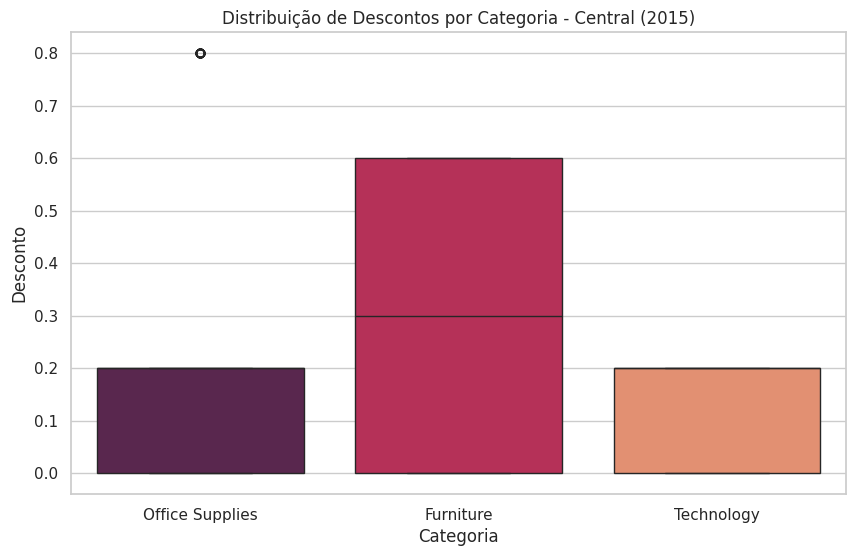

In [136]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - Central (2015)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


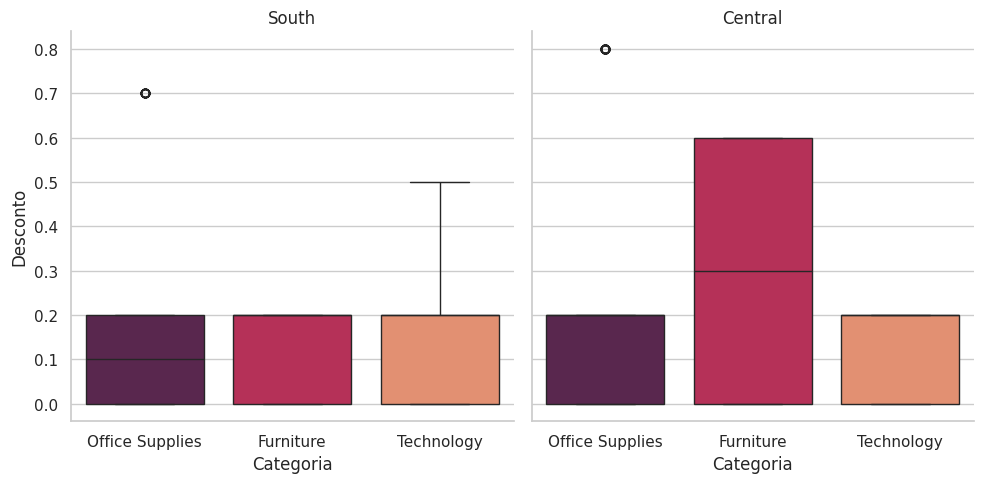

In [148]:
dados = df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

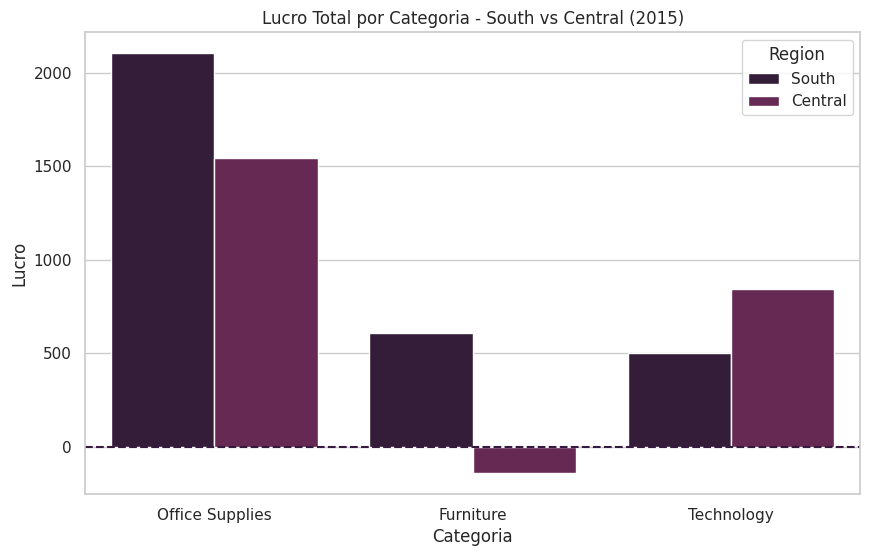

In [149]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'].isin(['Central', 'South']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2015)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

- Aqui podemos ver como uma distribuição de descontos inteligente é importante, mesmo sendo uma categoria pouco rentável, ela não aceita muitos descontos altos. Então mesmo perdendo um lucro de uma categoria muito rentável, como technology, ela ocmpensou uma parte desse lucro perdido com a categoria menos rentável, Furniture.

In [150]:
#. Exibindo os dados estatísticos da Região com a menor rentabilidade do Ano de 2016
df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304,304.0
mean,4895.121711,34189.013158,50.600424,3.585526,0.161513,9.940907,2016-07-23 12:18:56.842105344,2016.0
min,70.000000,22153.000000,2.214000,1.000000,0.000000,-34.758000,2016-01-05 00:00:00,2016.0
25%,2686.750000,28205.000000,14.122500,2.000000,0.000000,2.359000,2016-05-05 00:00:00,2016.0
50%,4798.500000,32216.000000,33.145000,3.000000,0.200000,6.430400,2016-08-04 00:00:00,2016.0
75%,7078.500000,37167.000000,71.230000,5.000000,0.200000,15.563750,2016-10-15 00:00:00,2016.0
max,9807.000000,72701.000000,225.296000,13.000000,0.700000,60.255300,2016-12-31 00:00:00,2016.0
std,2627.334486,11258.366566,49.385441,2.061574,0.220408,16.736459,NaN,0.0


- De novo, podemos ver que os outliers já não causam tanto impacto nesse ano. Porém, ainda podemos ver valores distantes, no caso do min e max.

In [151]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')]['Category'].value_counts()}\n")

Category
Furniture          0.102222
Office Supplies    0.180090
Technology         0.123684
Name: Discount, dtype: float64

Category
Furniture          0.4
Office Supplies    0.7
Technology         0.5
Name: Discount, dtype: float64

Discount
0.0    151
0.2    115
0.7     36
0.4      1
0.5      1
Name: count, dtype: int64

36

-409.5426

3022.0357000000004

Category
Furniture           625.6709
Office Supplies    1999.1877
Technology          397.1771
Name: Profit, dtype: float64

Category
Office Supplies    221
Furniture           45
Technology          38
Name: count, dtype: int64



- Aqui podemos ver que não foram realizadas tantas vendas com altos descontos. Porém, a categoria Office Supplies recebeu um desconto médio de 18%, o que não é muito. Mas, significa que ele recebeu desocntos grandes, o que fez sua média subir e por ser uma categoria rentável, acaba resultando em uma perda de lucro que pode ser significativa.

/tmp/ipykernel_12466/2717952382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')


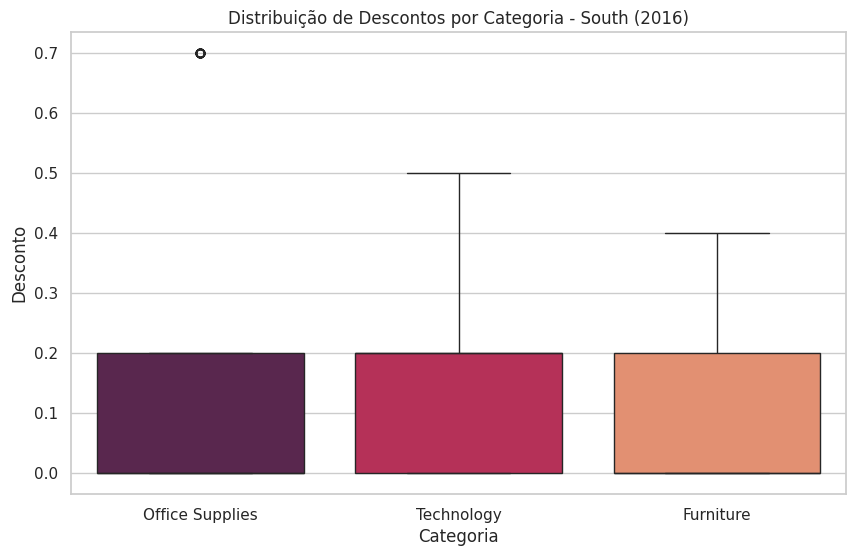

In [152]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - South (2016)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

- Além disso, a categoria Technology, muito rentável, também recebeu alguns desocntos altos. Já que, 25% das vendas dessa categoria rcebeu desocntos acima de 20% e menores que 50% que pode resultar em uma perda de rendimento considerável.

In [153]:
#. Exibindo os dados estatísticos da segunda região com a menor rentabilidade do Ano de 2016
df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441,441.0
mean,4943.723356,65854.253968,45.828857,3.630385,0.225170,7.859095,2016-08-15 07:24:04.897959168,2016.0
min,22.000000,46203.000000,0.836000,1.000000,0.000000,-38.215800,2016-01-03 00:00:00,2016.0
25%,2347.000000,55106.000000,11.168000,2.000000,0.000000,-0.756600,2016-06-11 00:00:00,2016.0
50%,4730.000000,68025.000000,24.700000,3.000000,0.200000,4.495500,2016-09-02 00:00:00,2016.0
75%,7563.000000,77041.000000,62.958000,5.000000,0.200000,15.378000,2016-11-04 00:00:00,2016.0
max,9984.000000,79907.000000,224.750000,12.000000,0.800000,69.920000,2016-12-30 00:00:00,2016.0
std,2941.478131,11353.833301,50.126495,2.155729,0.258715,17.575700,NaN,0.0


- Novamente, podemos ver que os outliers não causam mais problemas gritantes. Entretanto, ainda existem valores distantes na base.

In [154]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')]['Category'].value_counts()}\n")

Category
Furniture          0.346875
Office Supplies    0.225902
Technology         0.113889
Name: Discount, dtype: float64

Category
Furniture          0.6
Office Supplies    0.8
Technology         0.2
Name: Discount, dtype: float64

Discount
0.2    184
0.0    162
0.8     50
0.6     32
0.3     10
0.1      3
Name: count, dtype: int64

82

-894.9712999999999

3465.8611

Category
Furniture           -99.8111
Office Supplies    2399.8888
Technology         1165.7834
Name: Profit, dtype: float64

Category
Office Supplies    305
Technology          72
Furniture           64
Name: count, dtype: int64



- Podemos ver que nessa região temos muitas vendas com alto descontos. Porém, podemos ver que a categoria que mais recebeu esses descontos altos foi a Furniture, categoria pouco rentável e a categoria Technology, altamente rentável, não recebeu tantos descontos assim, se mantendo com uma média baixa. Dessa forma, a categoria altamente rentável conseguiu compensar o lucro perdido pela categoria de baixo valor agregado.

/tmp/ipykernel_12466/568903319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')


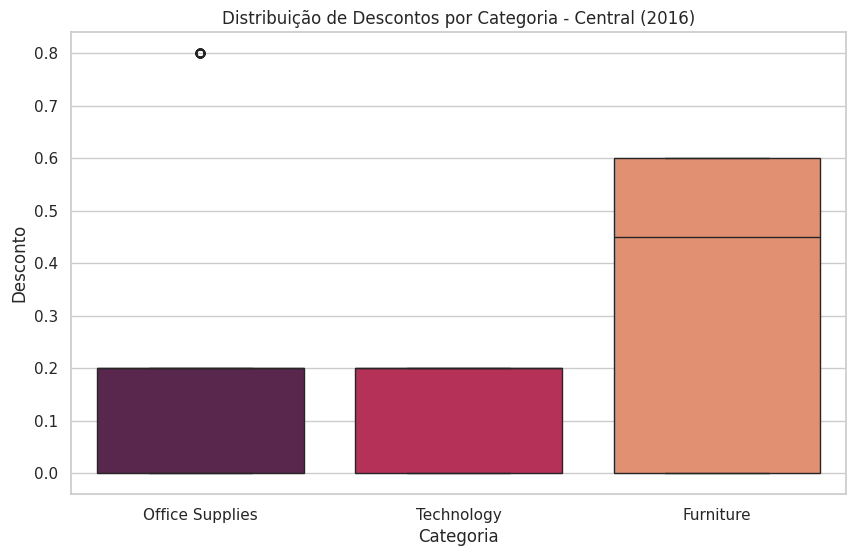

In [156]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - Central (2016)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


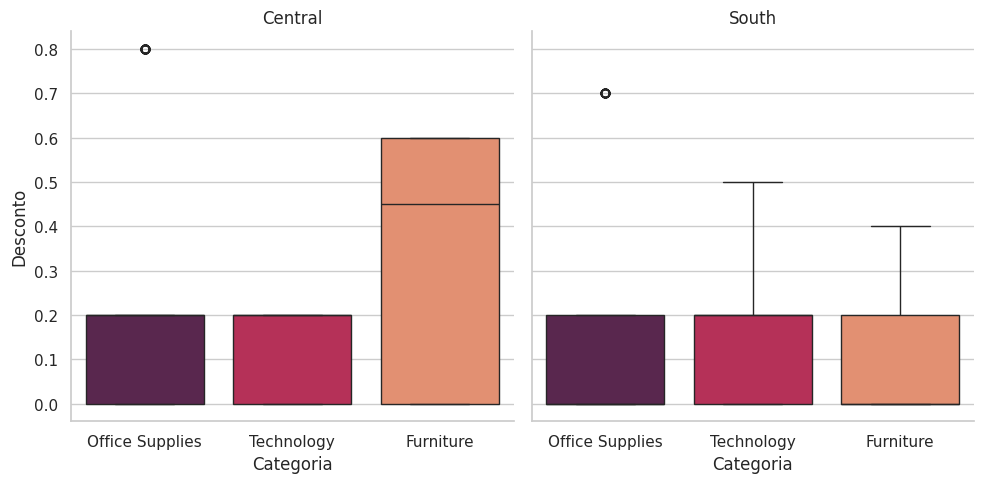

In [167]:
dados = df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

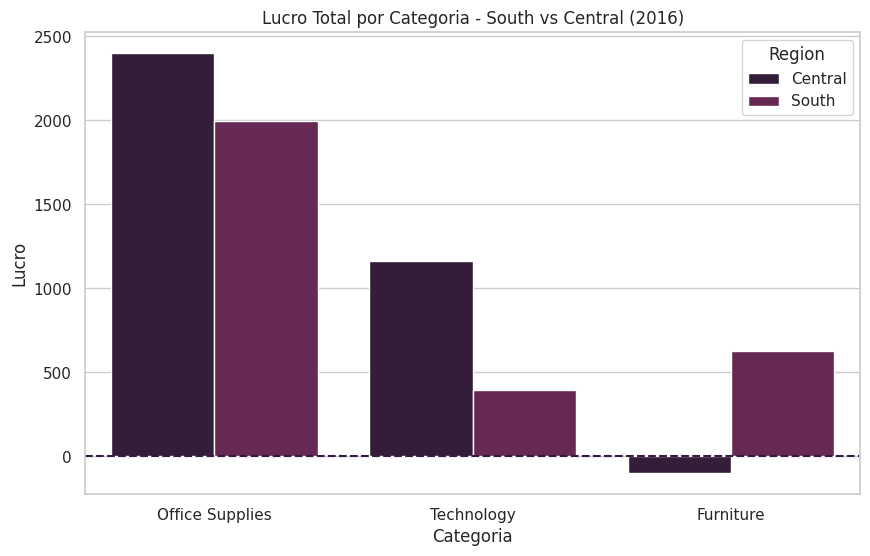

In [168]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'].isin(['South', 'Central']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2016)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

In [159]:
df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561,561.0
mean,4966.698752,65082.149733,46.443514,3.491979,0.226916,7.092857,2017-07-30 04:06:25.026738176,2017.0
min,35.000000,46142.000000,0.444000,1.000000,0.000000,-39.637000,2017-01-01 00:00:00,2017.0
25%,2572.000000,55407.000000,10.400000,2.000000,0.000000,-1.041000,2017-05-11 00:00:00,2017.0
50%,4860.000000,62301.000000,24.180000,3.000000,0.200000,4.674600,2017-08-17 00:00:00,2017.0
75%,7445.000000,77036.000000,61.792000,5.000000,0.200000,13.438600,2017-11-06 00:00:00,2017.0
max,9952.000000,79907.000000,227.976000,14.000000,0.800000,70.492800,2017-12-30 00:00:00,2017.0
std,2886.686187,11184.280128,52.474142,2.123934,0.261642,18.296225,NaN,0.0


- Mais uma vez, podemos ver que os outliers não causam mais impacto na descrição dos dados. Porém, valores distantes ainda aparecem na base.

In [160]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')]['Category'].value_counts()}\n")

Category
Furniture          0.324615
Office Supplies    0.232927
Technology         0.124419
Name: Discount, dtype: float64

Category
Furniture          0.6
Office Supplies    0.8
Technology         0.3
Name: Discount, dtype: float64

Discount
0.20    241
0.00    204
0.80     72
0.60     28
0.30     10
0.32      5
0.10      1
Name: count, dtype: int64

100

-1175.5609000000002

3979.0928

Category
Furniture           -95.2411
Office Supplies    2711.2289
Technology         1363.1050
Name: Profit, dtype: float64

Category
Office Supplies    410
Technology          86
Furniture           65
Name: count, dtype: int64



- Aqui podemos ver que ela realizou muitas vendas com altos descontos, que resultaram em um prejuízo alto. Porém, a maior parte desses descontos foram aplicados a categoria de Furniture, o que pode não ter trazido tanto impacto para o lucro final da região.

/tmp/ipykernel_12466/3190180975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')


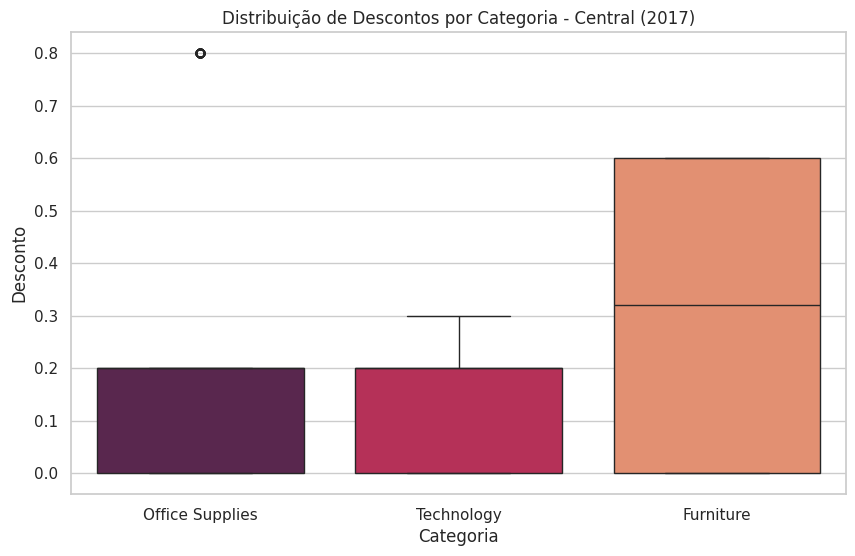

In [161]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - Central (2017)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [162]:
#. Exibindo os dados estatísticos da segunda região com a menor rentabilidade do Ano de 2017
df_clean[(df['Year'] == 2017) & (df_clean['Region'] == 'South')].describe()

/tmp/ipykernel_12466/888151857.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean[(df['Year'] == 2017) & (df_clean['Region'] == 'South')].describe()


,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit,Order_Date_Formatado,Year
count,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379,379.0
mean,5474.949868,35129.203166,50.209375,3.443272,0.163588,8.966852,2017-08-11 11:35:18.205804800,2017.0
min,13.000000,22153.000000,1.584000,1.000000,0.000000,-36.111600,2017-01-02 00:00:00,2017.0
25%,2971.500000,29444.500000,13.394000,2.000000,0.000000,1.360300,2017-05-25 12:00:00,2017.0
50%,5562.000000,33012.000000,27.580000,3.000000,0.200000,5.517700,2017-09-07 00:00:00,2017.0
75%,7965.500000,37918.000000,67.468000,5.000000,0.200000,15.246900,2017-11-04 00:00:00,2017.0
max,9989.000000,72762.000000,222.384000,9.000000,0.700000,70.312000,2017-12-29 00:00:00,2017.0
std,2797.864561,10281.560990,54.571095,1.948769,0.193256,17.249623,NaN,0.0


- Por fim, podemos ver que os outliers não possuem mais tanto impacto assim. Porém, valores distantes existem.

In [163]:
#. Exibindo a média de desconto aplicado para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')].groupby('Category').Discount.mean()}\n")

#. Exibindo o desconto máximo para cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')].groupby('Category').Discount.max()}\n")

#. Verificando a frequência dos descontos que foram aplicados
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')]['Discount'].value_counts().sort_values(ascending=False)}\n")

#. Pegando a quantidade de Vendas que foram realizadas com descontos acima de 50%
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)].shape[0]}\n")

#. Exibindo o lucro que foi produzido por essas vendas com o desconto maior que 50%
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South') & (df_clean['Discount'] > 0.5)]['Profit'].sum()}\n")

#. Exibindo o lucro total dessa região nesse ano
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')]['Profit'].sum()}\n")

#. Verificando a Rentabilidade por cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')].groupby('Category').Profit.sum()}\n")

#. Verificando quantas vendas foram realizadas em cada categoria
print(f"{df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')]['Category'].value_counts()}\n")

Category
Furniture          0.147368
Office Supplies    0.179008
Technology         0.111667
Name: Discount, dtype: float64

Category
Furniture          0.4
Office Supplies    0.7
Technology         0.5
Name: Discount, dtype: float64

Discount
0.2    188
0.0    155
0.7     33
0.4      2
0.5      1
Name: count, dtype: int64

33

-374.514

3398.4370000000004

Category
Furniture           289.9805
Office Supplies    2241.8830
Technology          866.5735
Name: Profit, dtype: float64

Category
Office Supplies    262
Technology          60
Furniture           57
Name: count, dtype: int64



- Aqui podemos ver que a região não realizou muitas vendas com altos descontos, mesmo que deram um prejuízo no final, não sendo tão impactante para o lucro final da região. Além disso, a distribuição dos descontos foi equilibrada, o que ajudou na obtenção de um lucro saudável.

/tmp/ipykernel_12466/3488182397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')


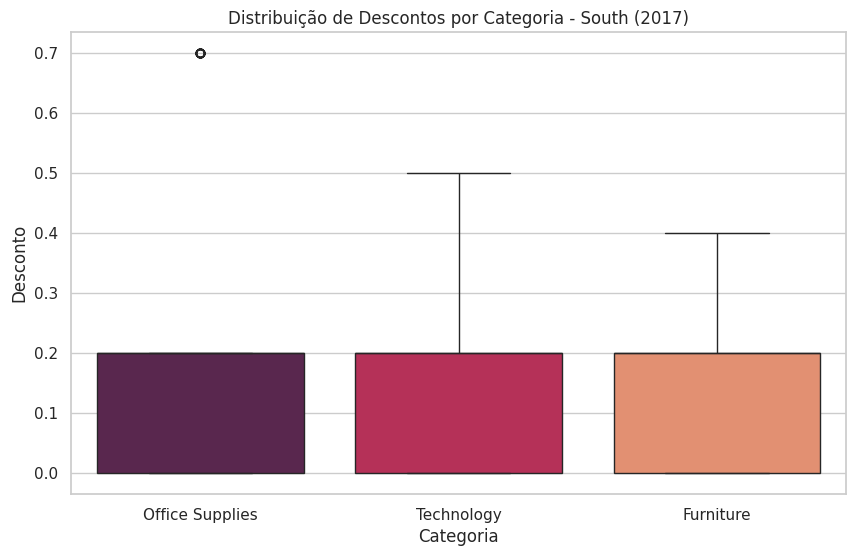

In [164]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')], x='Category', y='Discount', palette='rocket')

plt.title('Distribuição de Descontos por Categoria - South (2017)')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


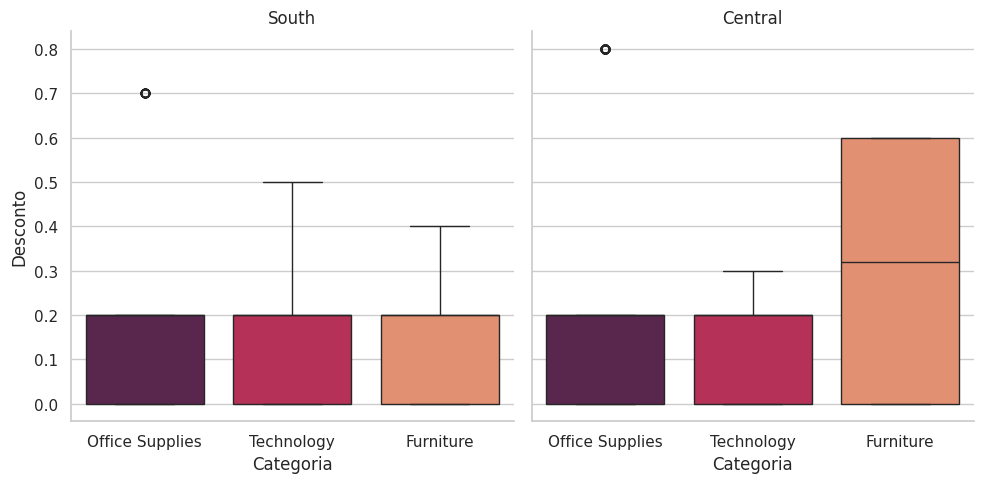

In [169]:
dados = df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'].isin(['Central', 'South']))]

g = sns.FacetGrid(dados, col='Region', height=5, sharey=True)

g.map_dataframe(sns.boxplot, x='Category', y='Discount', palette='rocket')

g.set_titles(col_template='{col_name}')
g.set_axis_labels('Categoria', 'Desconto')

plt.show()

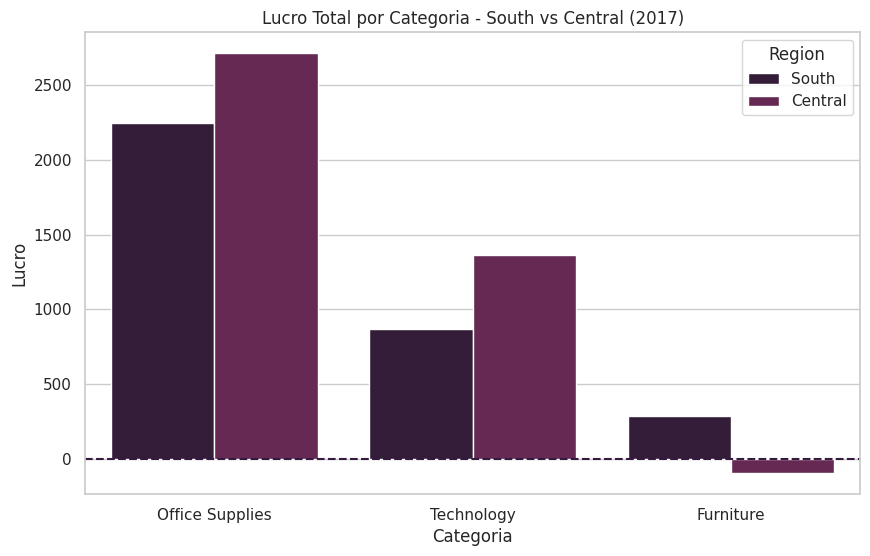

In [165]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'].isin(['South', 'Central']))], x='Category', y='Profit', hue='Region', estimator=sum, errorbar=None)

plt.axhline(0, linestyle='--')

plt.title('Lucro Total por Categoria - South vs Central (2017)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.show()

### Analisando a Distribuição de Dados das Regiões ao longo dos Anos

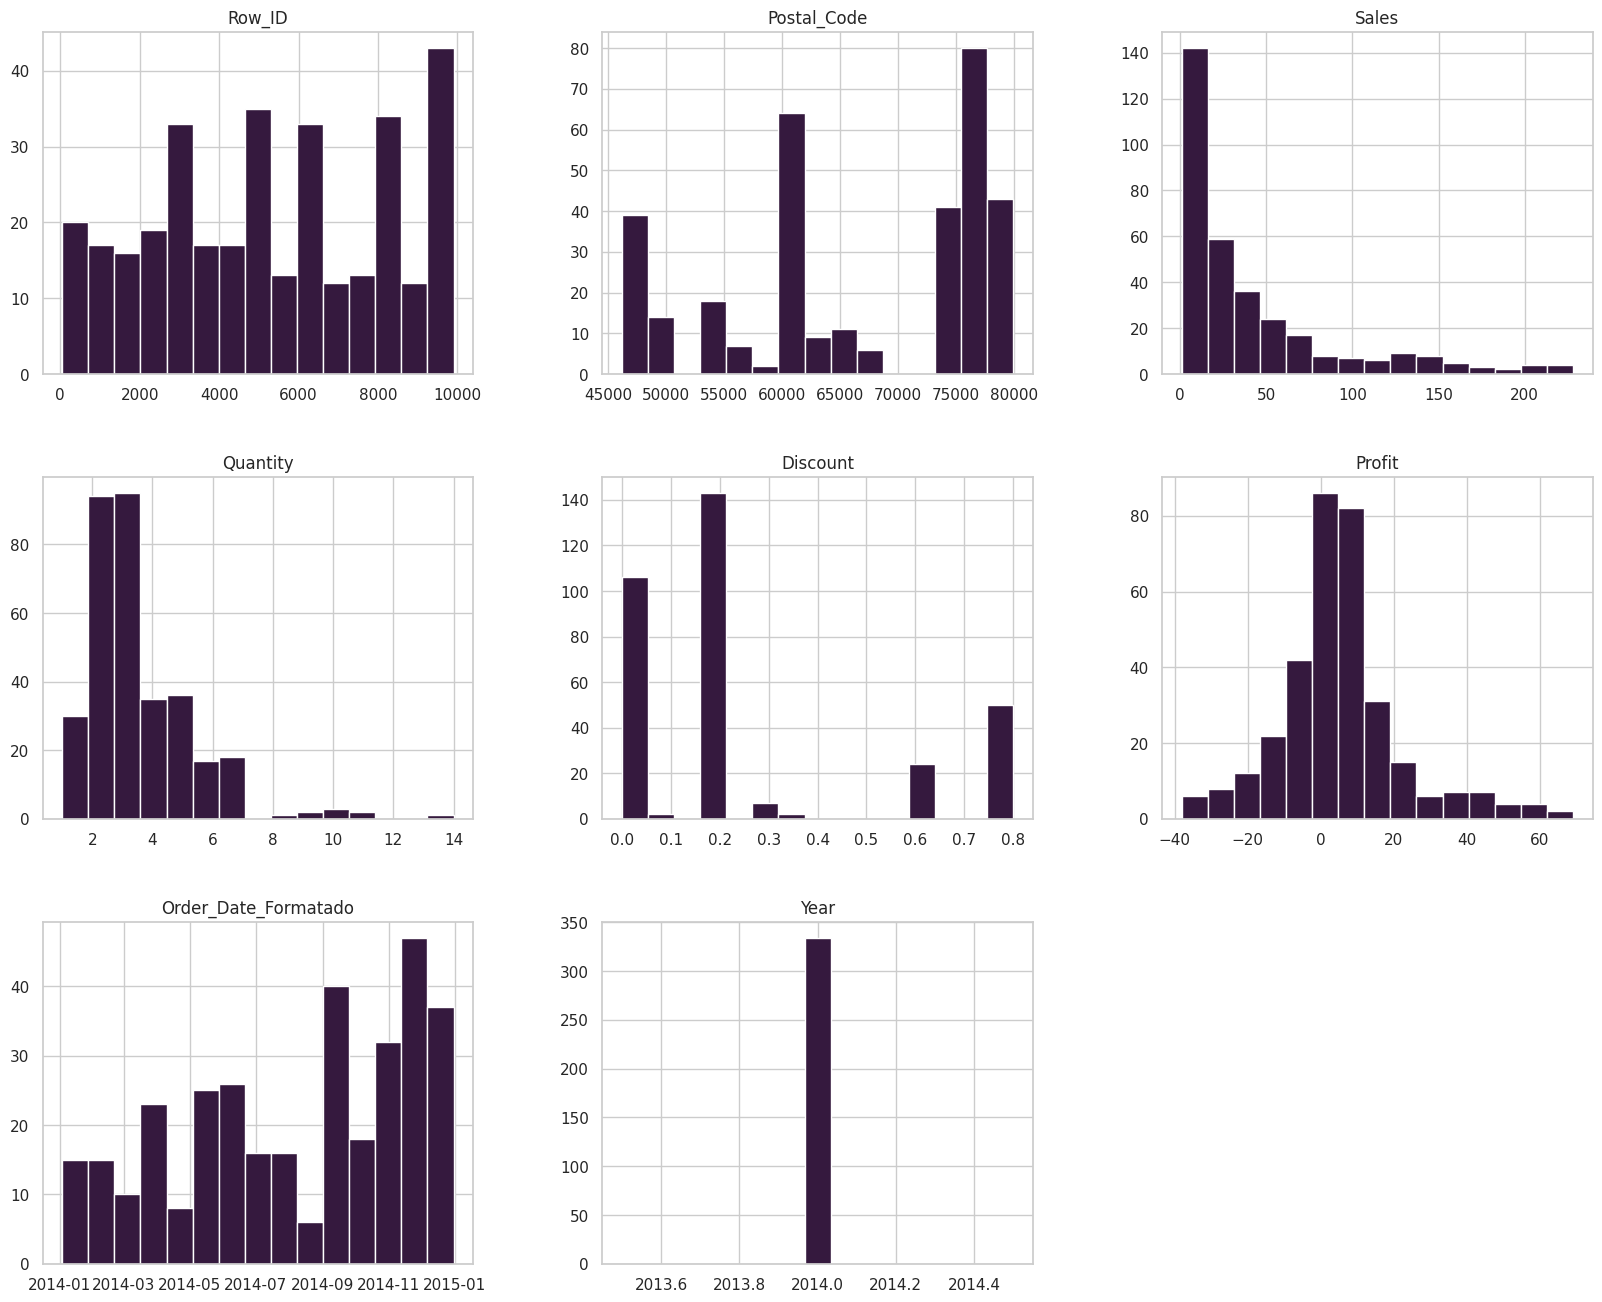

In [171]:
df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'Central')].hist(bins=15, figsize=(20,16));

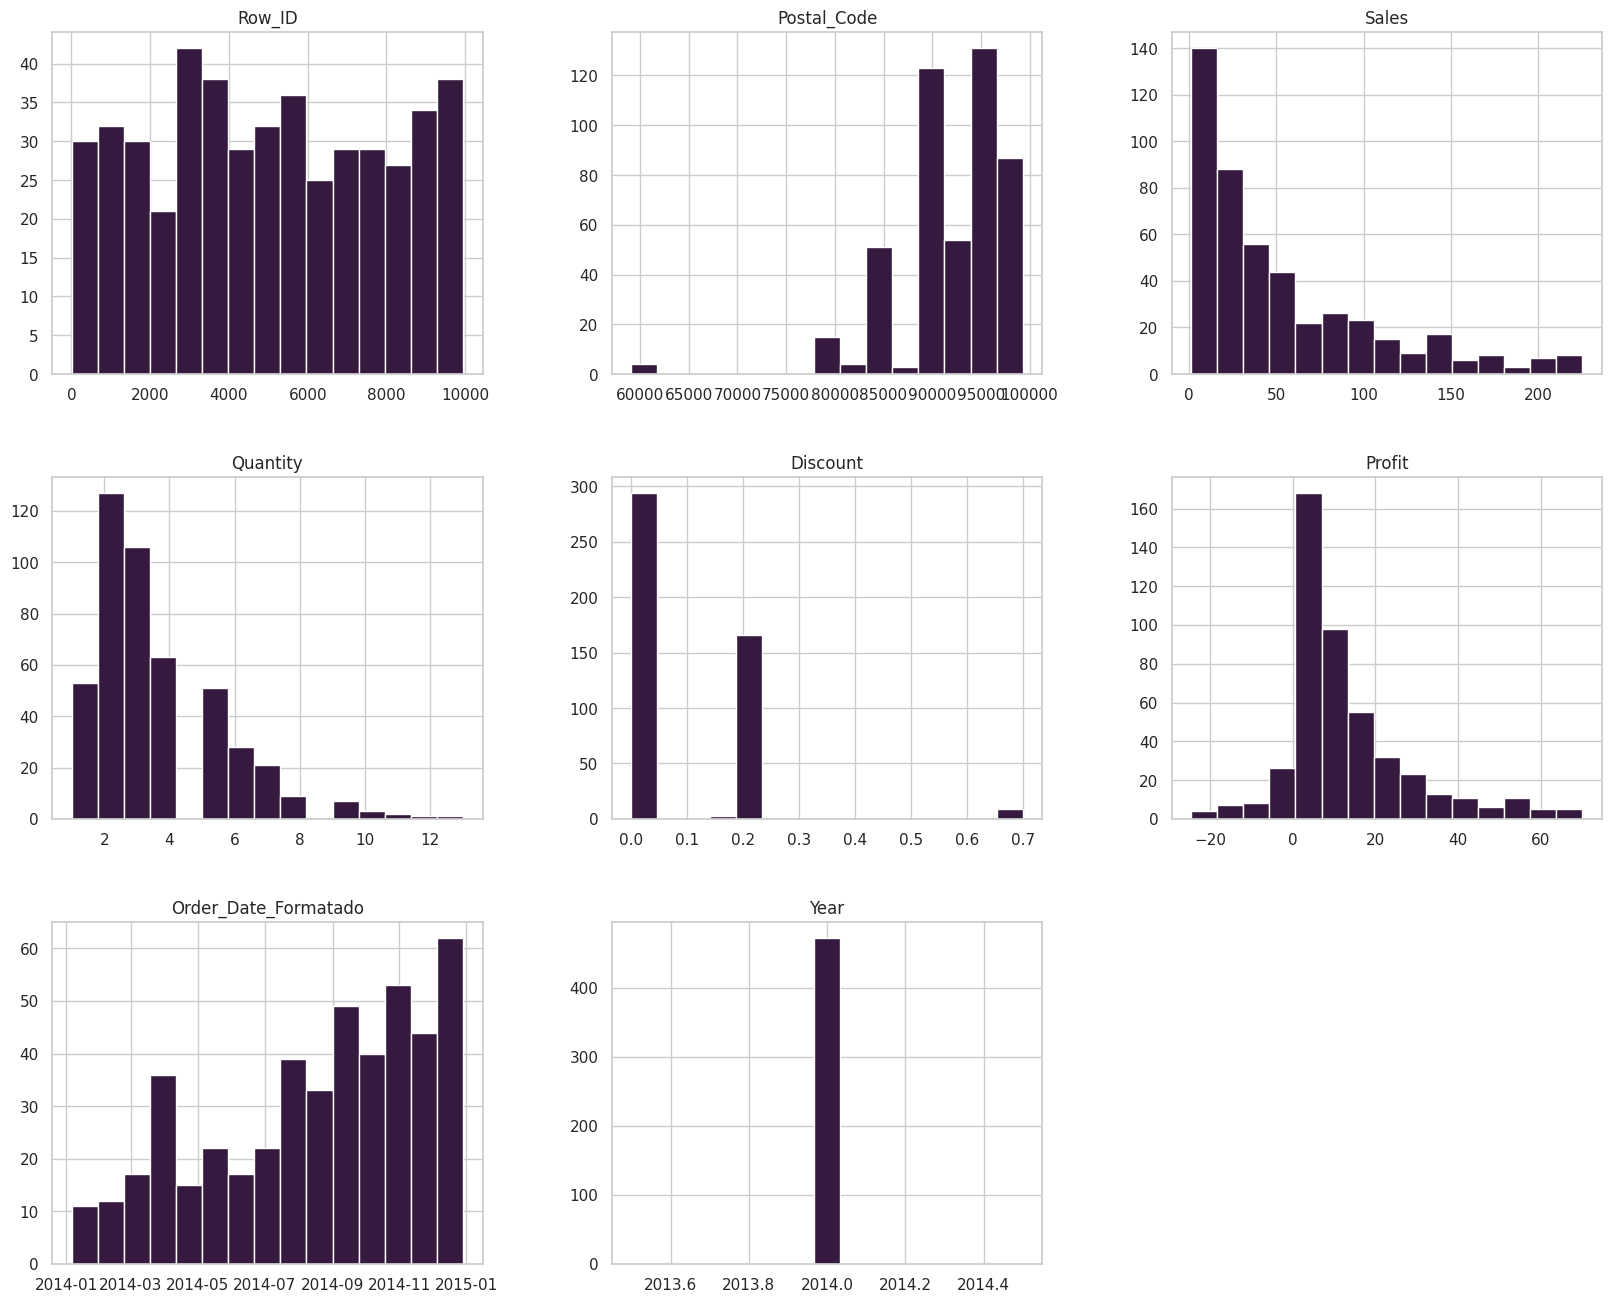

In [172]:
df_clean[(df_clean['Year'] == 2014) & (df_clean['Region'] == 'West')].hist(bins=15, figsize=(20,16));

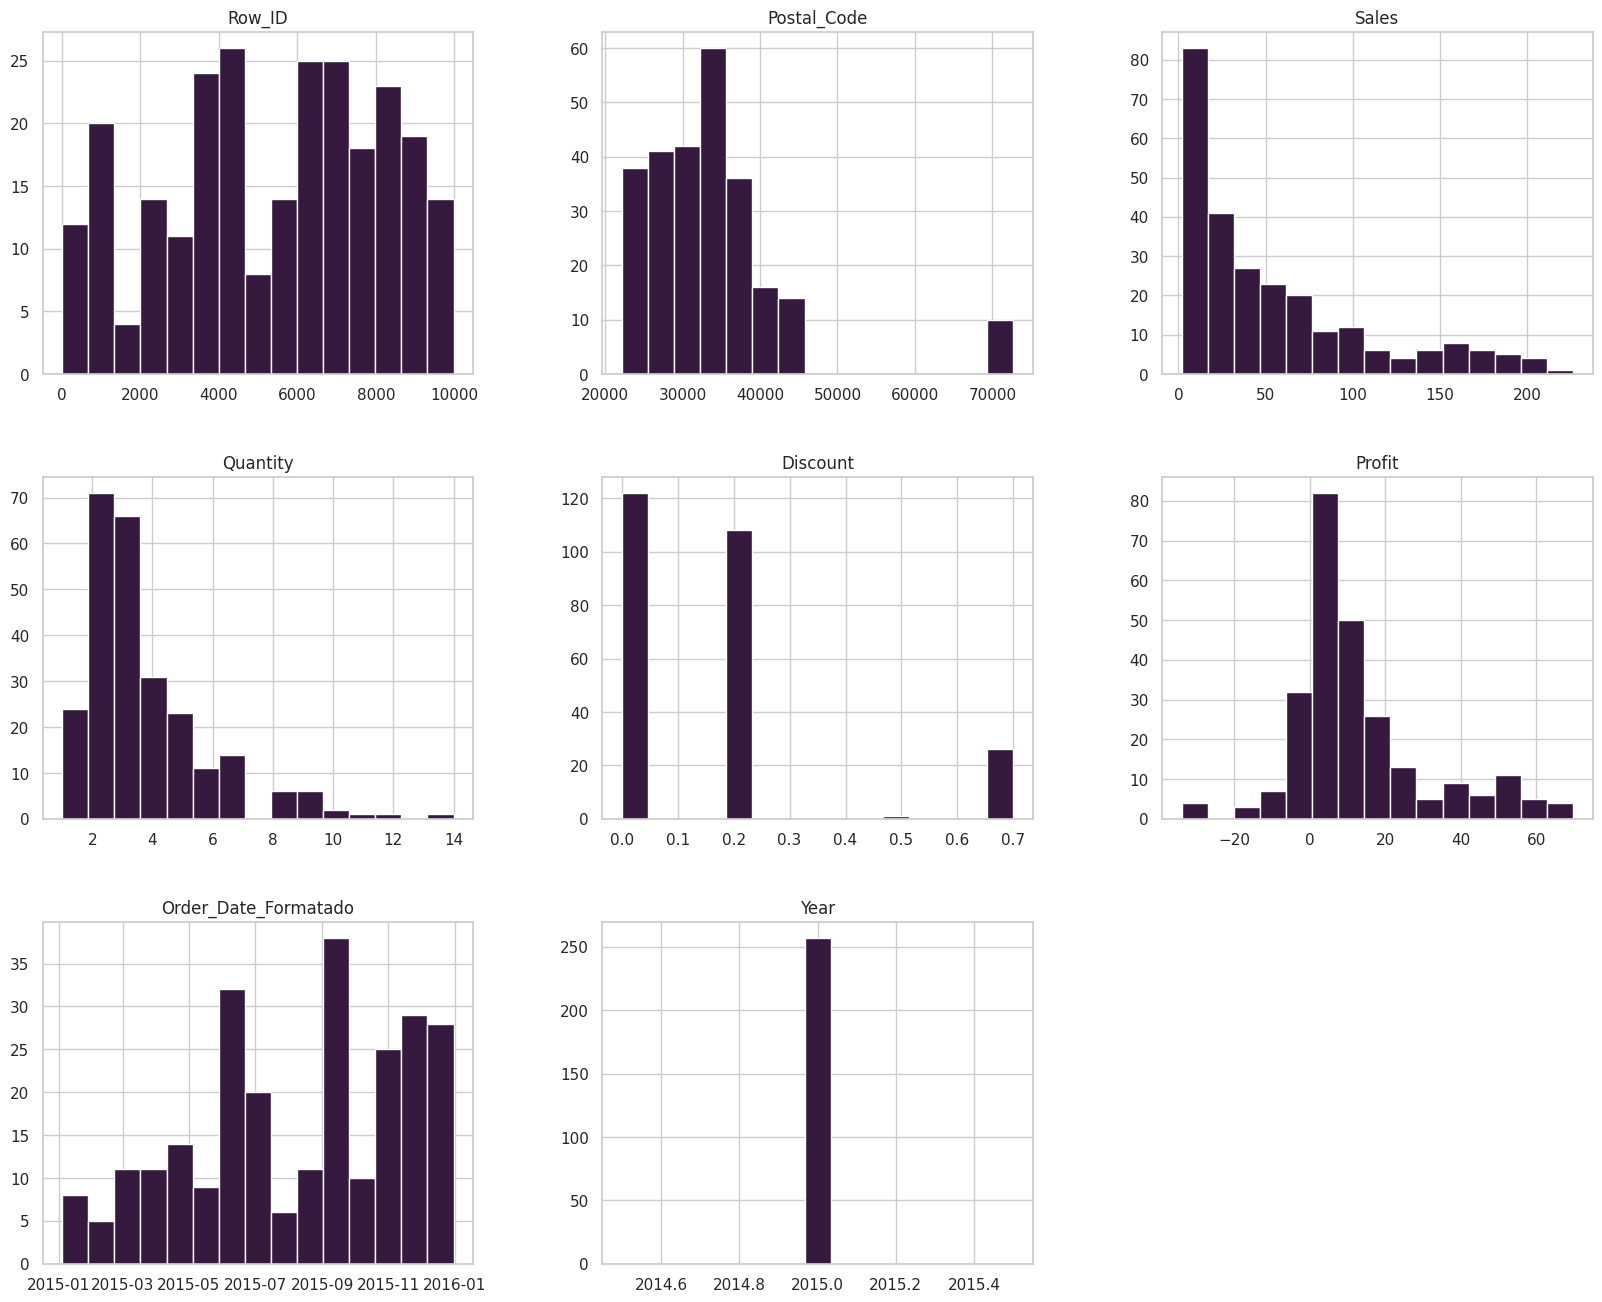

In [173]:
df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'South')].hist(bins=15, figsize=(20,16));

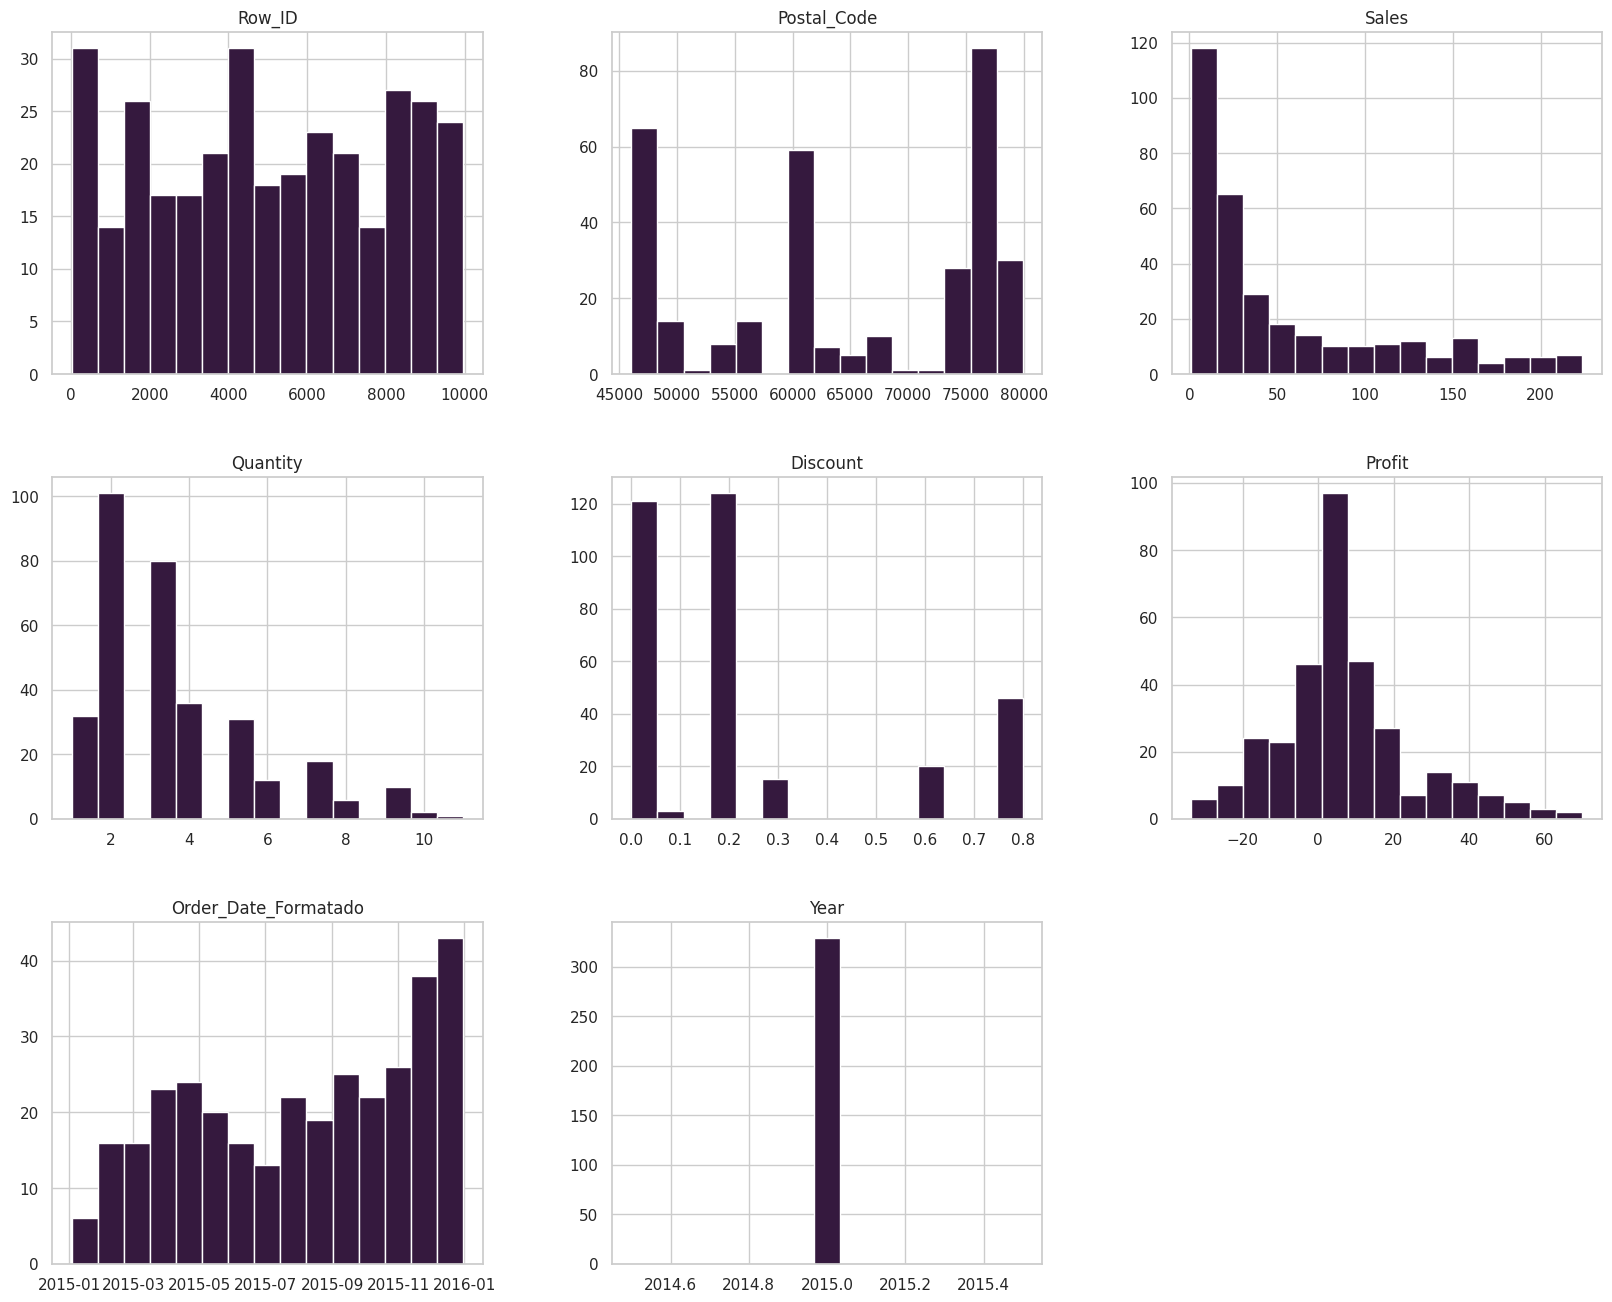

In [174]:
df_clean[(df_clean['Year'] == 2015) & (df_clean['Region'] == 'Central')].hist(bins=15, figsize=(20,16));

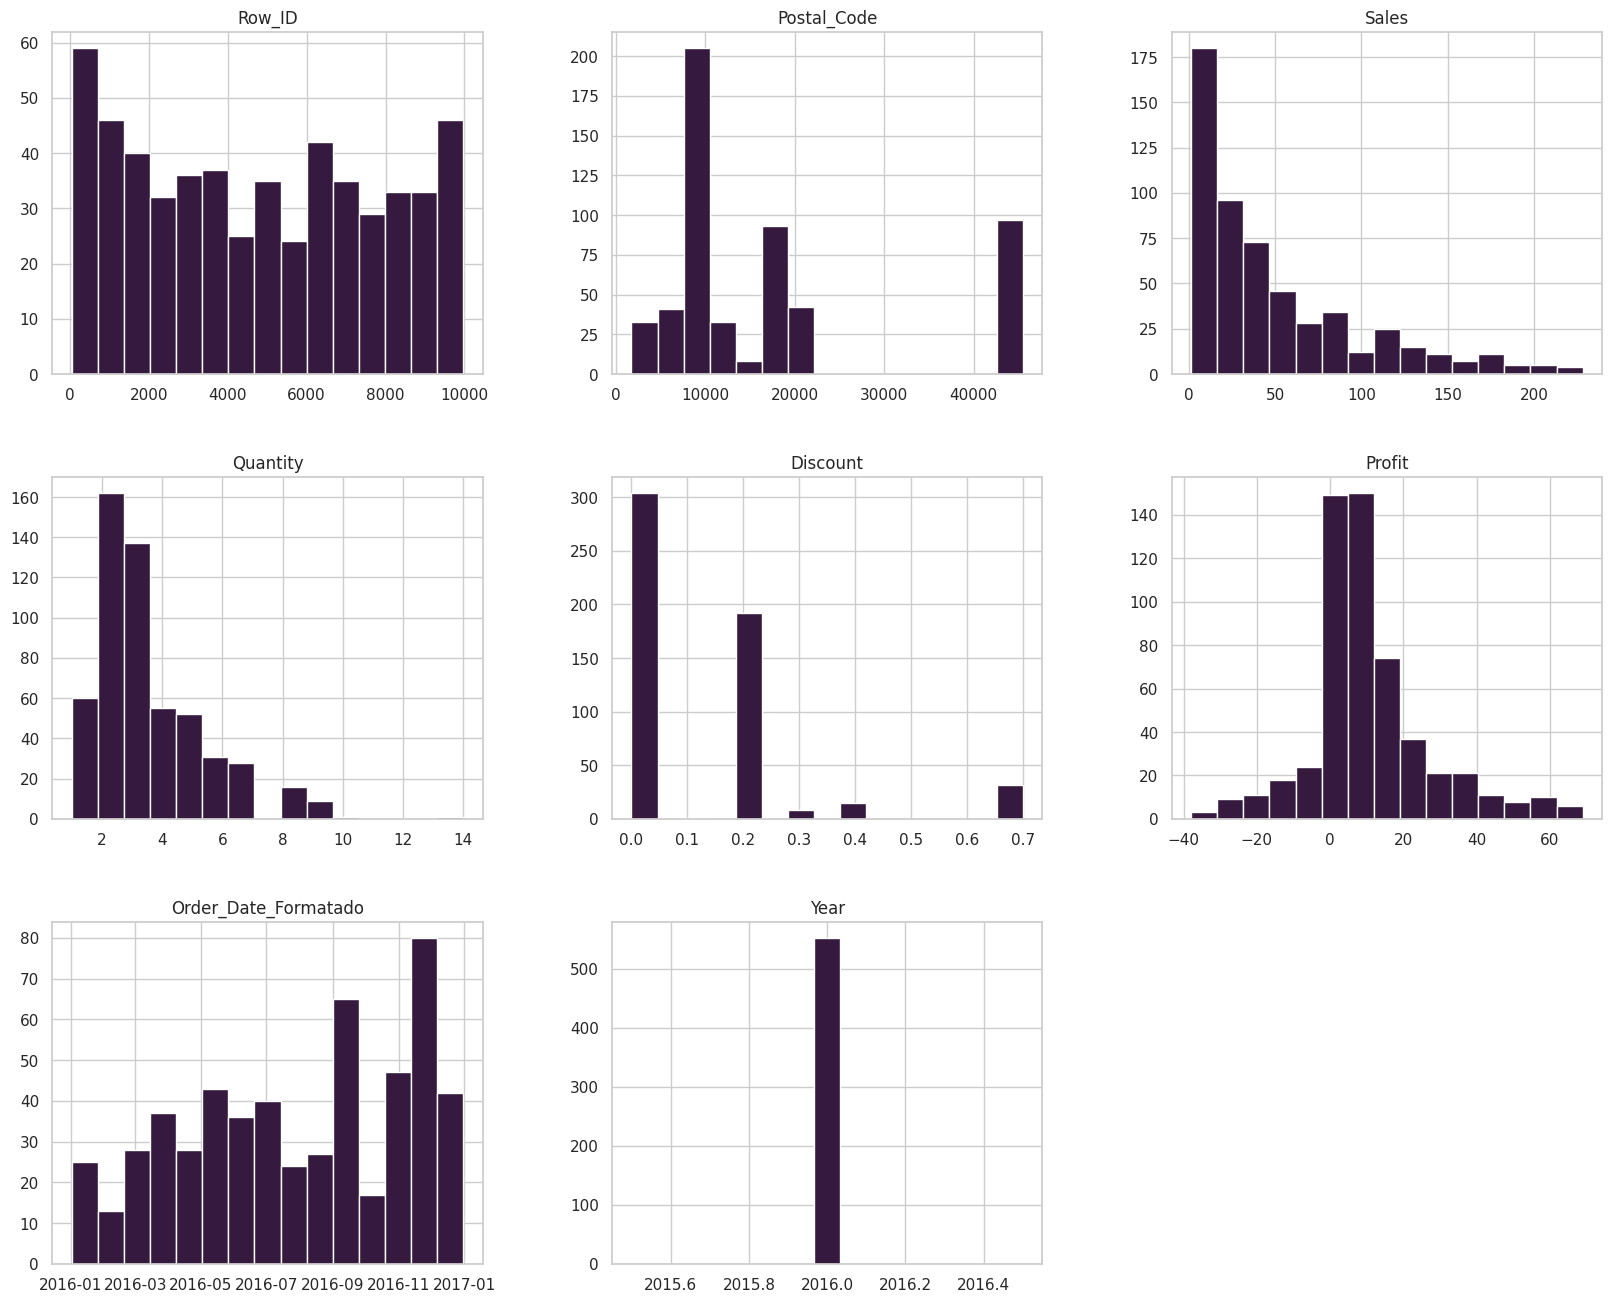

In [175]:
df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'East')].hist(bins=15, figsize=(20,16));

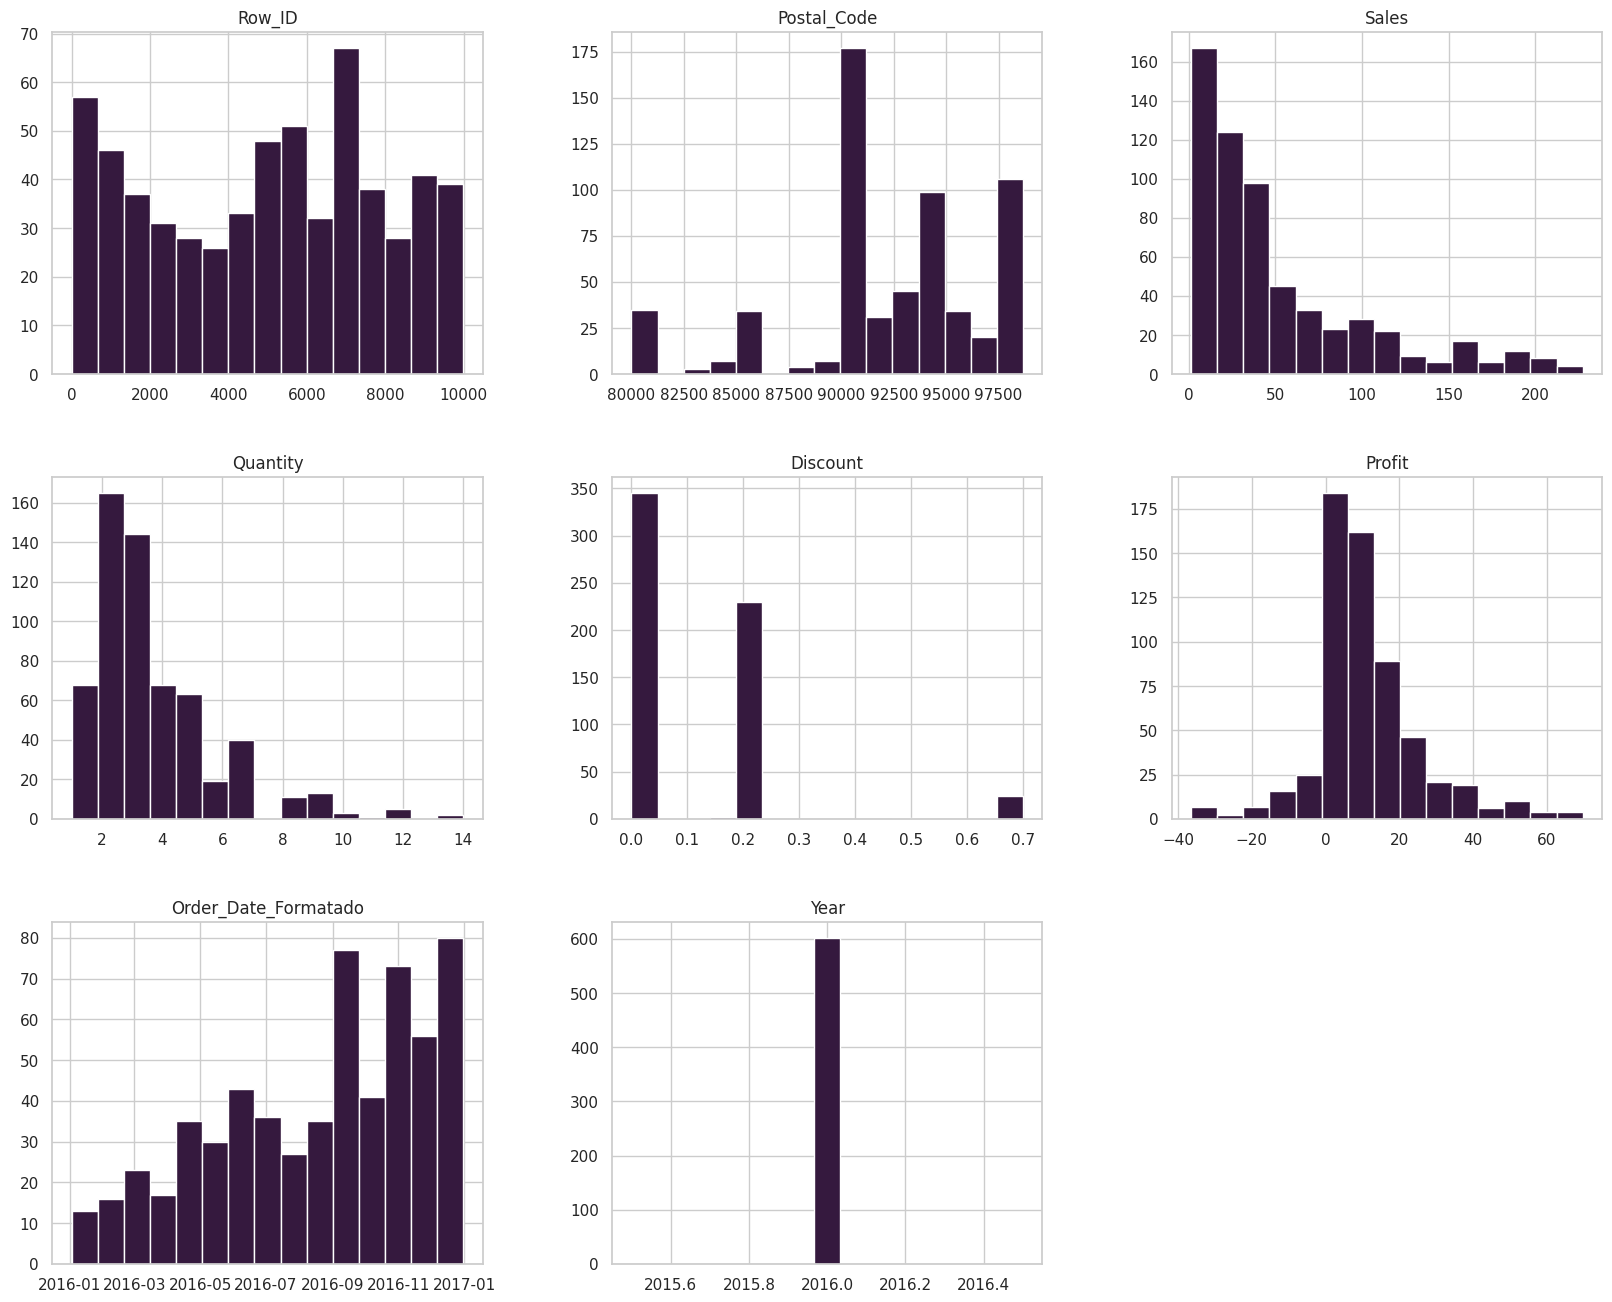

In [176]:
df_clean[(df_clean['Year'] == 2016) & (df_clean['Region'] == 'West')].hist(bins=15, figsize=(20,16));

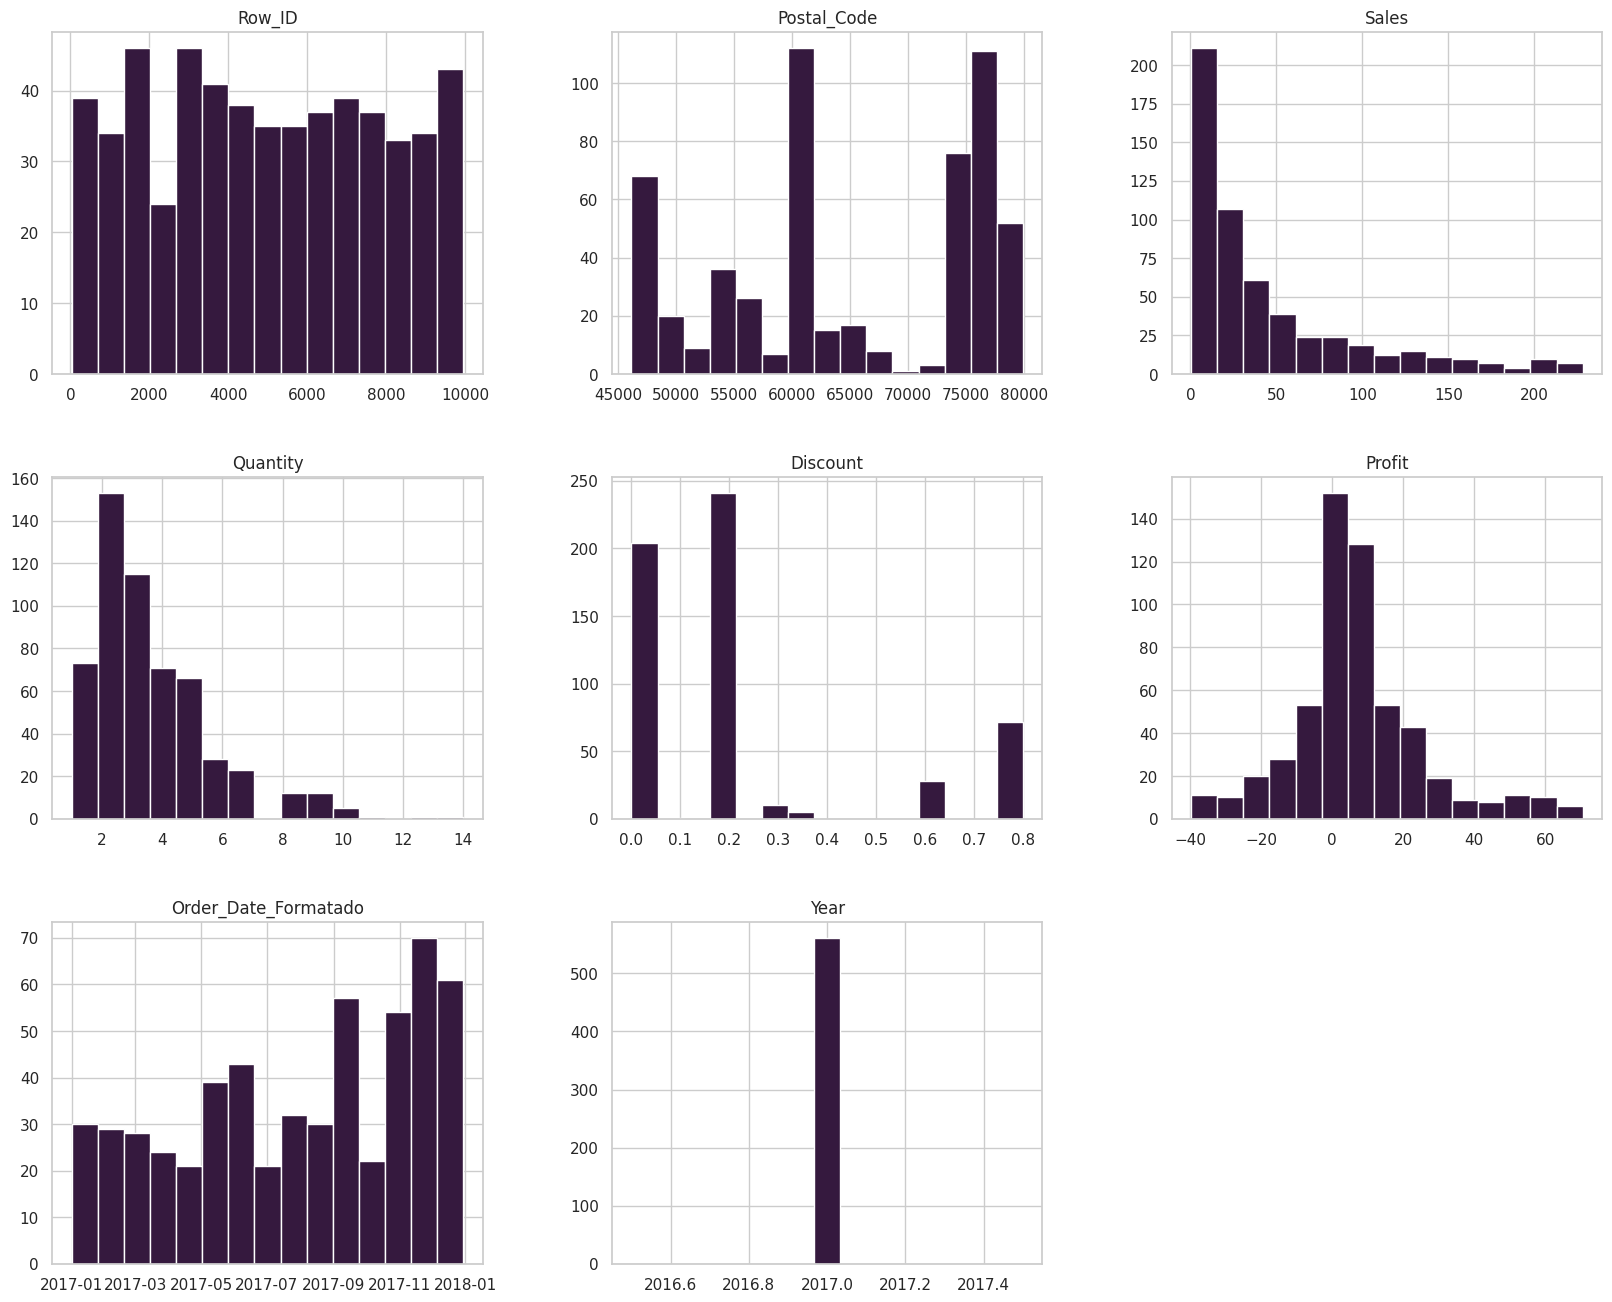

In [177]:
df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'Central')].hist(bins=15, figsize=(20,16));

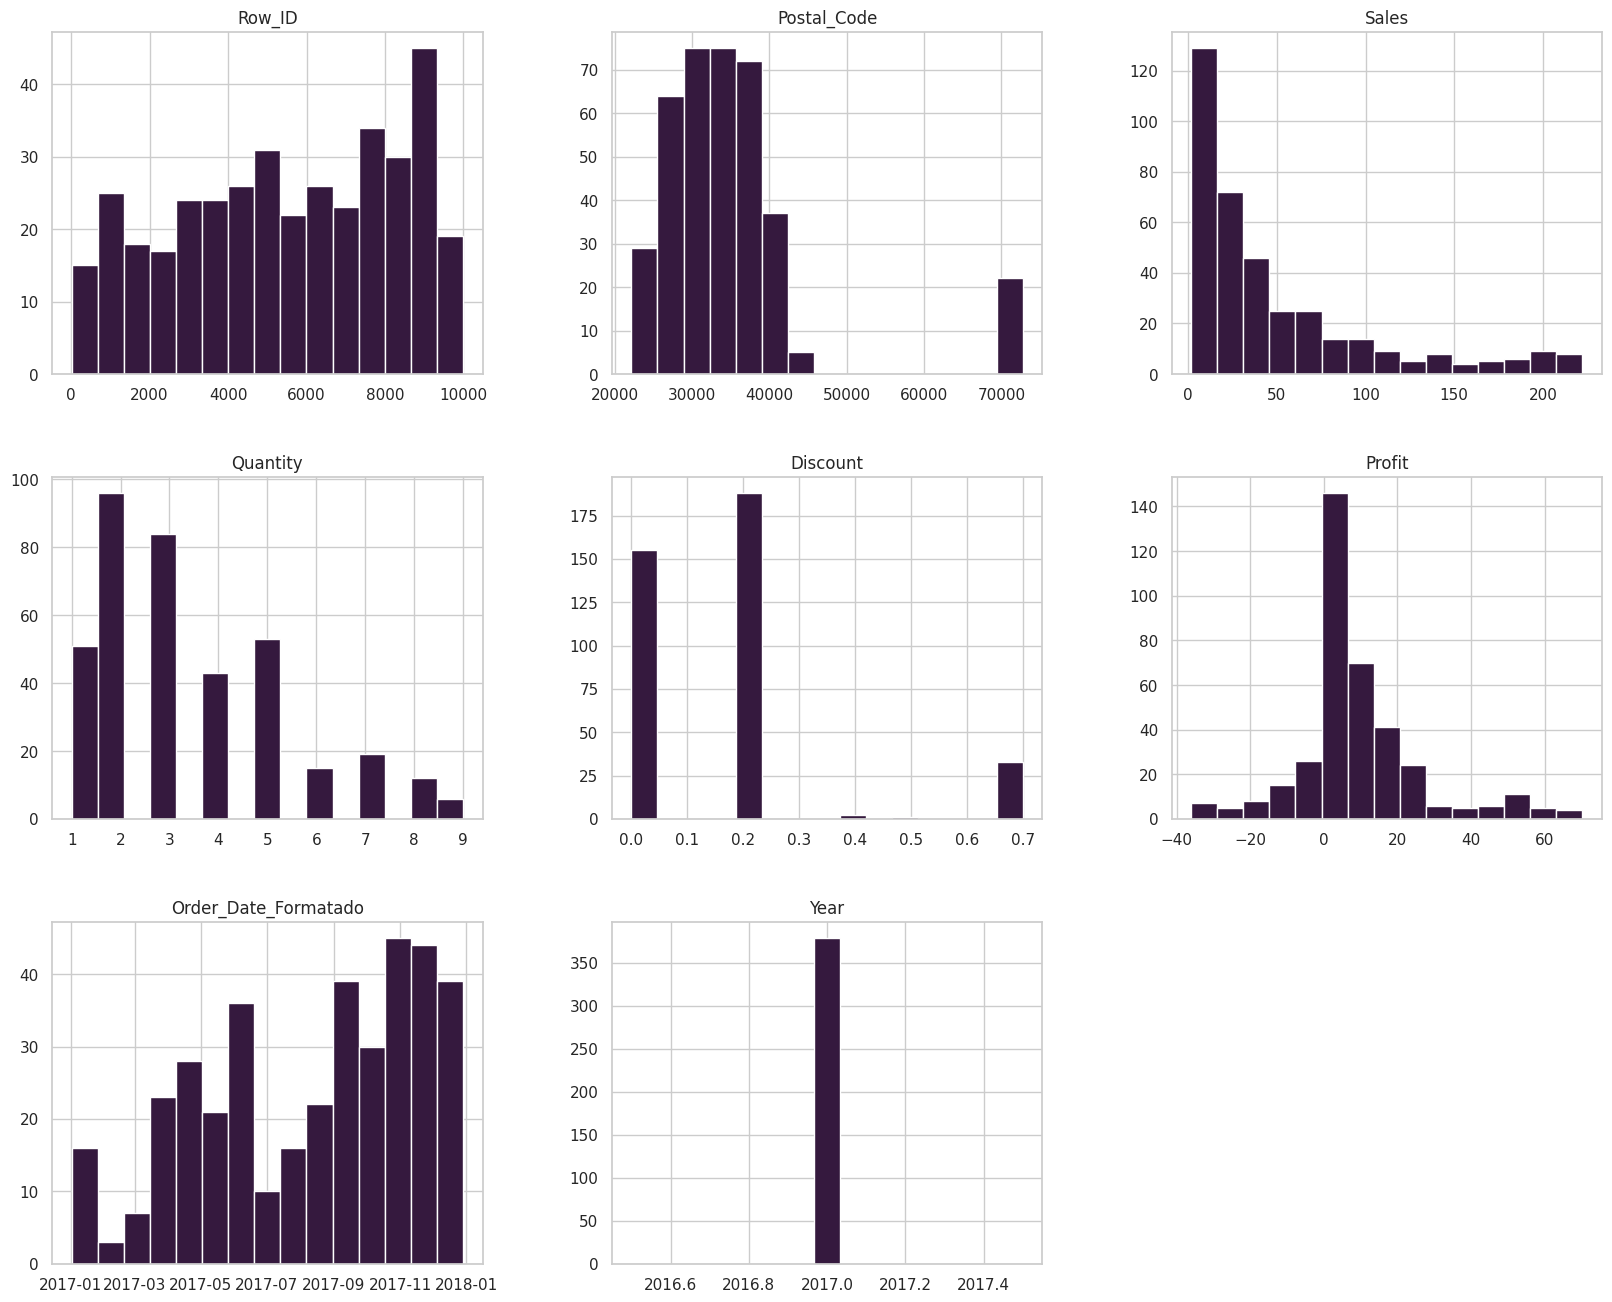

In [178]:
df_clean[(df_clean['Year'] == 2017) & (df_clean['Region'] == 'South')].hist(bins=15, figsize=(20,16));

- Ao analisar a distribuição de dados das regiões podemos confirmar que realmente essas regiões não sofrem mais tanto impacto com os outliers e sua variávéis já seguem um fluxo de distribuição normal.

### Conclusão Análise Regiões com Baixa Rentabilidade

- Após realizar algumas análises, podemos concluir que essas regiões apresentam uma baixa rentabilidade por um conjunto de fatores: Vendas com Altos Descontos e também apresentam uma quantidade alta de vendas de uma categoria que não é tão lucrativa que são os produtos de Furniture.

##Analisando clientes com baixa rentabilidade


### Análise dos 10 Piores Clientes de 2014

In [179]:
#. Filtrando os 10 clientes que mais dão Prejuízo no ano de 2014

rentabilidade_clientes = df_clean[df_clean['Year'] == 2014].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)
print(rentabilidade_clientes)

Customer_Name
Luke Foster         -73.2418
Shahid Collister    -61.1577
Kelly Lampkin       -48.3876
Michael Dominguez   -47.3384
Craig Carroll       -45.3169
Guy Phonely         -35.9280
Sarah Bern          -33.3918
George Bell         -33.1954
Katherine Hughes    -32.4108
Nona Balk           -30.2288
Name: Profit, dtype: float64


- Podemos observar que Luke Foster foi o cliente que mais deu prejuízo nesse ano, com uma certa vantagem do segundo colocado. Agora, precisamos saber o porquê

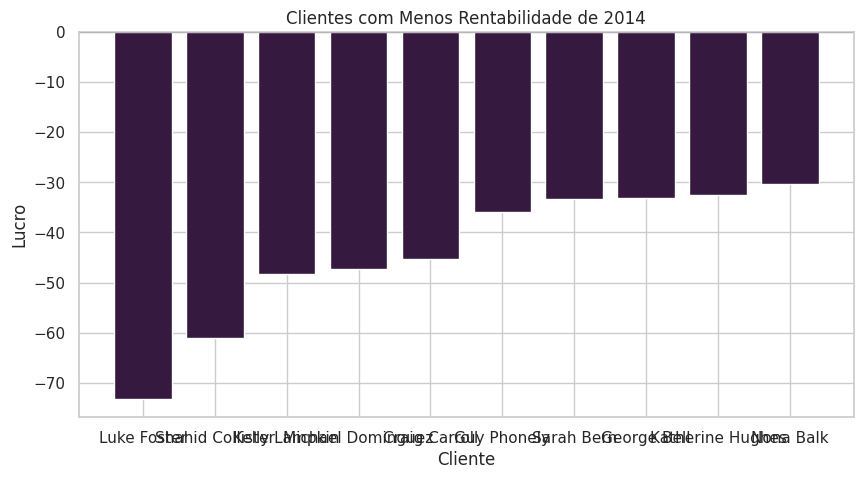

In [180]:
#. Plotando um gráfico de barras para demonstrar o prejuízo de cada Cliente

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes.index, rentabilidade_clientes.values)

plt.title('Clientes com Menos Rentabilidade de 2014')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Uma das possibilidades desse alto prejuízo, é de que o cliente consome podutos da categoria que costuma dar prejuízo na empresa ou ele recebe uma grande quantidade de descontos. Vamos dar seguimento na análise.

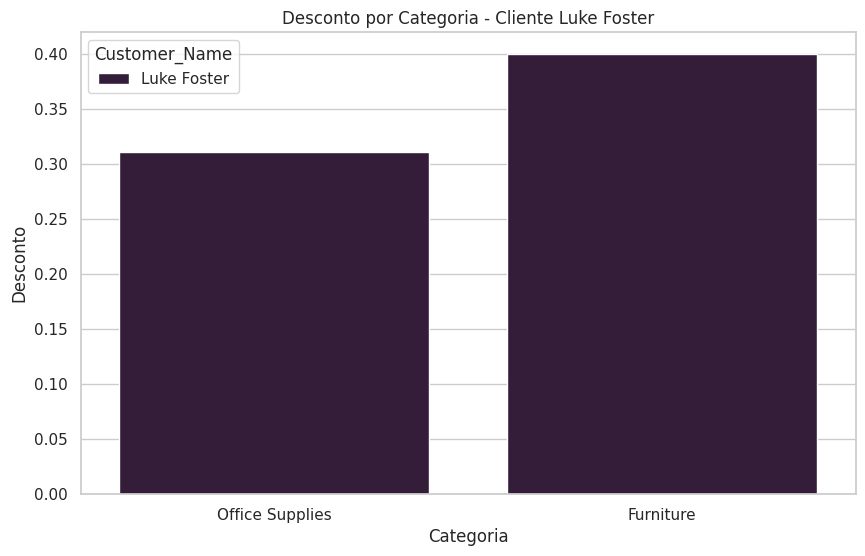

In [224]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Luke Foster'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Luke Foster')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [181]:
#. Verificando a quantidade de descontos altos que cada cliente recebeu

df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'].isin(rentabilidade_clientes.index)) & (df_clean['Discount'] > 0.5)]['Customer_Name'].value_counts()

,count
Customer_Name,
Luke Foster,5
Craig Carroll,2
Michael Dominguez,2
Kelly Lampkin,1
Guy Phonely,1
Sarah Bern,1
Shahid Collister,1
Katherine Hughes,1


- Podemos ver que o pior cliente desse ano realizou 5 compras com alto descontos. Por enquanto, o motivo do alto prejuízo causado foi esse.

/tmp/ipykernel_12466/4268733494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'].isin(rentabilidade_clientes.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes.sort_values().index, palette='rocket', showfliers=False)


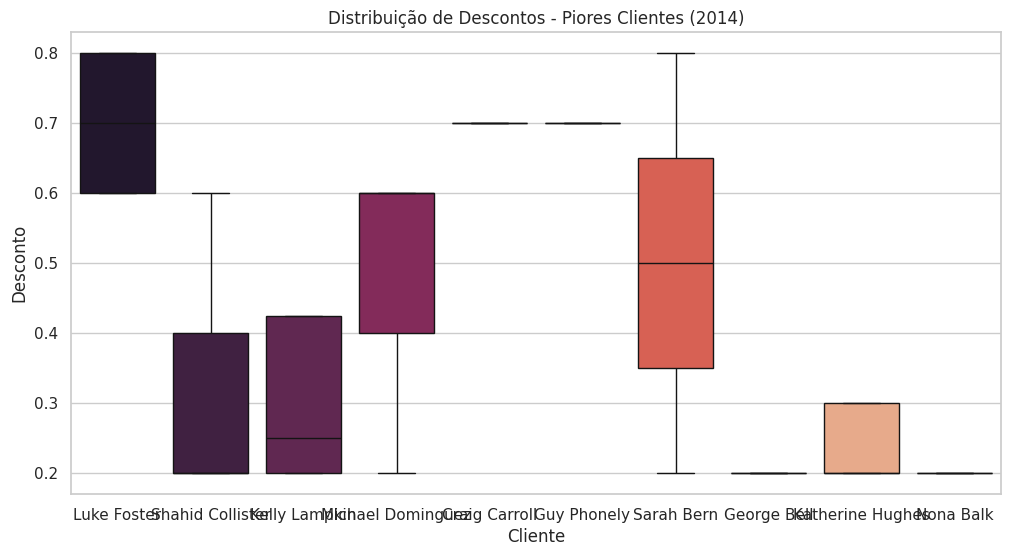

In [182]:
#. Plotando um boxplot para verificar a distribuição dos descontos que cada cliente recebeu

plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'].isin(rentabilidade_clientes.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes.sort_values().index, palette='rocket', showfliers=False)

plt.title('Distribuição de Descontos - Piores Clientes (2014)')
plt.xlabel('Cliente')
plt.ylabel('Desconto')

plt.show()

- Ao visualizar o gráfico, podemos ver que a mediana de desconto do pior cliente é 0.70, o que é muito alto.

In [183]:
#. Verificando quantas compras o pior cliente fez em cada categoria

df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')]['Category'].value_counts()

,count
Category,
Office Supplies,4
Furniture,2


- Podemos ver que ele comprou de uma categoria que costuma dar lucro para empresa. Então, a soma de comprar produto com alto valor agragado com um alto desconto resulta em um prejuízo para empresa.

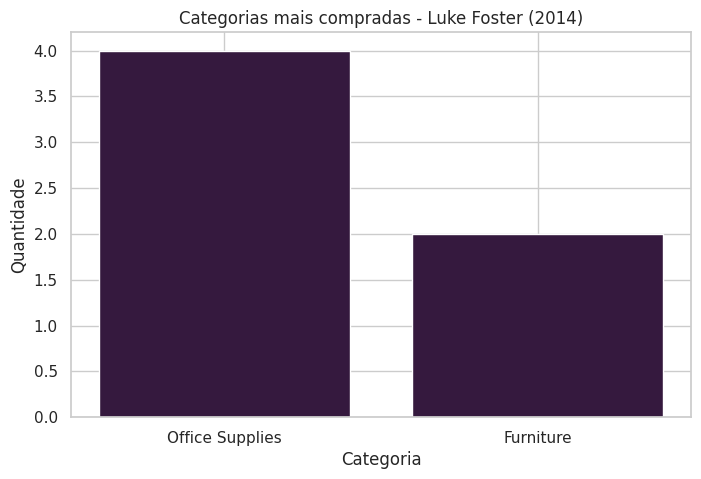

In [184]:
plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')]['Category'].value_counts().index, df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')]['Category'].value_counts().values)

plt.title('Categorias mais compradas - Luke Foster (2014)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.show()

In [185]:
#. Verificando qual foi o lucro/prejuízo resultante em cada categoria que esse cliente consumiu

df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,-24.4458
Office Supplies,-48.7960


- As compras feitas nessa categoria resultaram em muito prejuízo, comparado com as demais. Realmente, tudo indica que o problema maior foi o tamanho do desconto que esse cliente recebeu juntamente com a categoria onde esse desconto foi aplicado

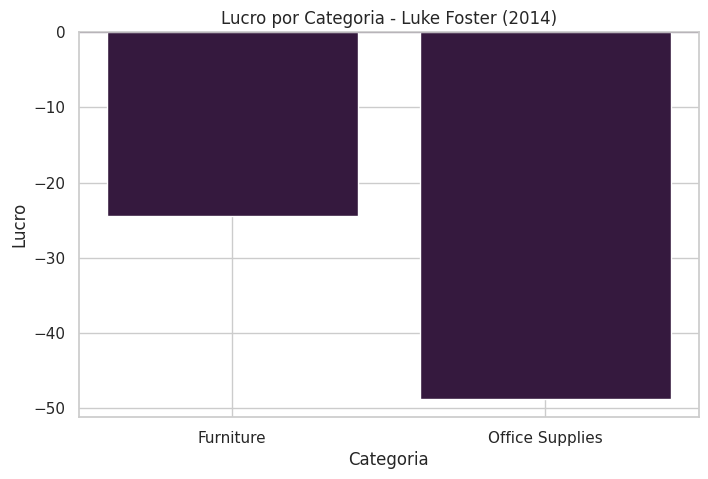

In [186]:
#. Plotando o lucro/Prejuízo que esse cliente produziu em suas compras

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Profit'].sum().index, df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Profit'].sum().values)

plt.title('Lucro por Categoria - Luke Foster (2014)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

In [187]:
#. Verificando a média de descontos que o cliente recebeu em cada categoria comprada.

df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Discount'].mean()

,Discount
Category,
Furniture,0.60
Office Supplies,0.65


- Aqui conseguimos concluir que o tamanho do desconto prejudicou muito o retorno que a empresa teria desse cliente. A categoria que mais deu prejuízo foi a que ele mais recebeu desconto.

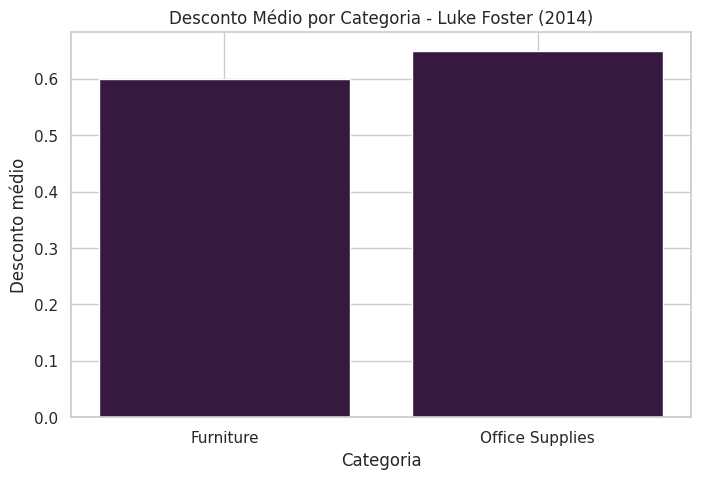

In [188]:
#. Plotando a média de desconto que o cliente recebeu em cada categoria.

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Discount'].mean().index, df_clean[(df_clean['Year'] == 2014) & (df_clean['Customer_Name'] == 'Luke Foster')].groupby('Category')['Discount'].mean().values)

plt.title('Desconto Médio por Categoria - Luke Foster (2014)')
plt.xlabel('Categoria')
plt.ylabel('Desconto médio')

plt.show()

- Aqui podemos concluir que, nesse ano, o pior cliente deu muito prejuízo para empresa devido aos altos descontos que lhe foram fornecidos.

### Análise dos 10 Piores Clientes de 2015

In [189]:
rentabilidade_clientes_2015 = df_clean[df_clean['Year'] == 2015].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)
print(rentabilidade_clientes_2015)

Customer_Name
Mick Crebagga     -73.0418
Cathy Armstrong   -47.7290
Dean Braden       -41.7939
Adrian Barton     -40.5056
Bryan Mills       -39.6629
Todd Sumrall      -37.1124
Seth Vernon       -36.2530
Max Jones         -35.1315
Debra Catini      -33.8418
Pamela Stobb      -33.1832
Name: Profit, dtype: float64


- Podemos ver que o pior cliente foi Mick Crebagga, com uma vantagem em relação ao segundo lugar.

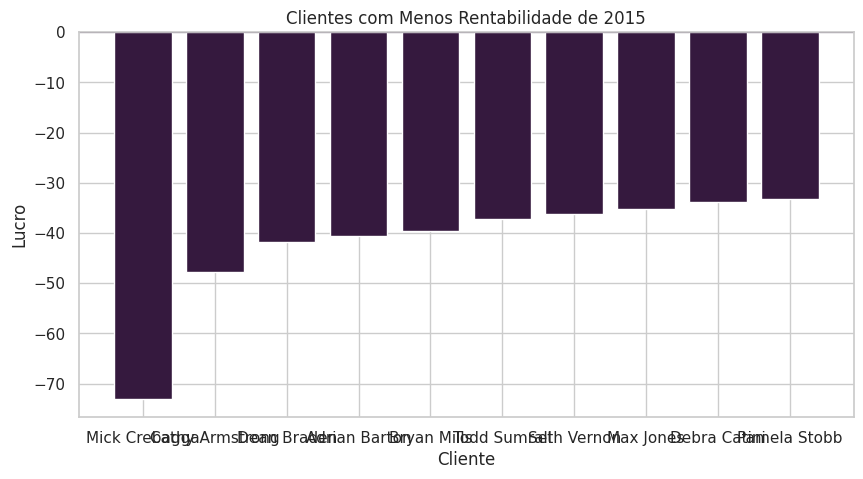

In [190]:
#. Plotando um gráfico de barras para demonstrar o prejuízo de cada Cliente

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2015.index, rentabilidade_clientes_2015.values)

plt.title('Clientes com Menos Rentabilidade de 2015')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

- Novamente, precisamos verificar qual foi o motivo do baixo rendimento desses clientes. Como vimos anteriormente, o tamanho do desconto pode ser o principal motivo do prejuízo causado, mesmo se tratando de categorias rentáveis.

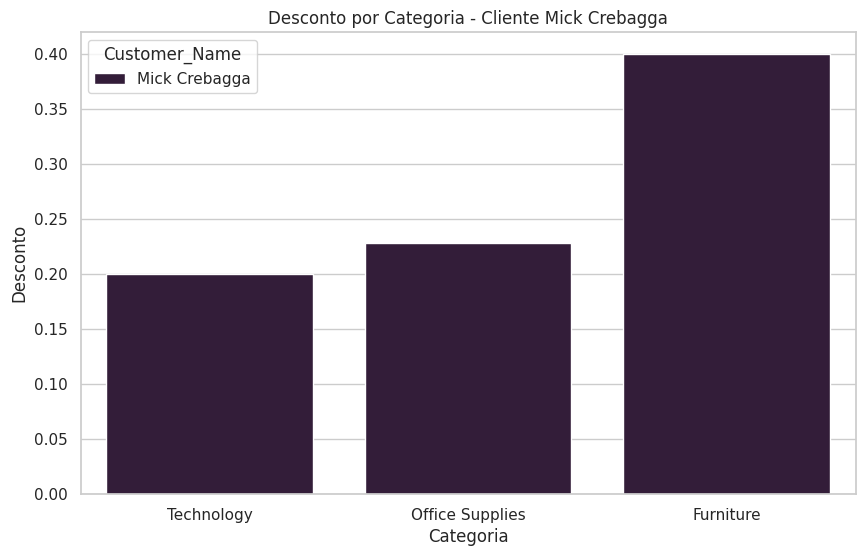

In [223]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Mick Crebagga'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Mick Crebagga')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [191]:
#. Verificando a quantidade de descontos altos que cada cliente recebeu

df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2015.index)) & (df_clean['Discount'] > 0.5)]['Customer_Name'].value_counts()

,count
Customer_Name,
Mick Crebagga,4
Cathy Armstrong,2
Bryan Mills,2
Dean Braden,1
Max Jones,1


- Podemos ver que os descontos não foram muito altos nesse ano. Uma possibilidade, é de que foi comprado produtos com baixa rentabilidade.

/tmp/ipykernel_12466/1478558508.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2015.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2015.sort_values().index, palette='rocket', showfliers=False)


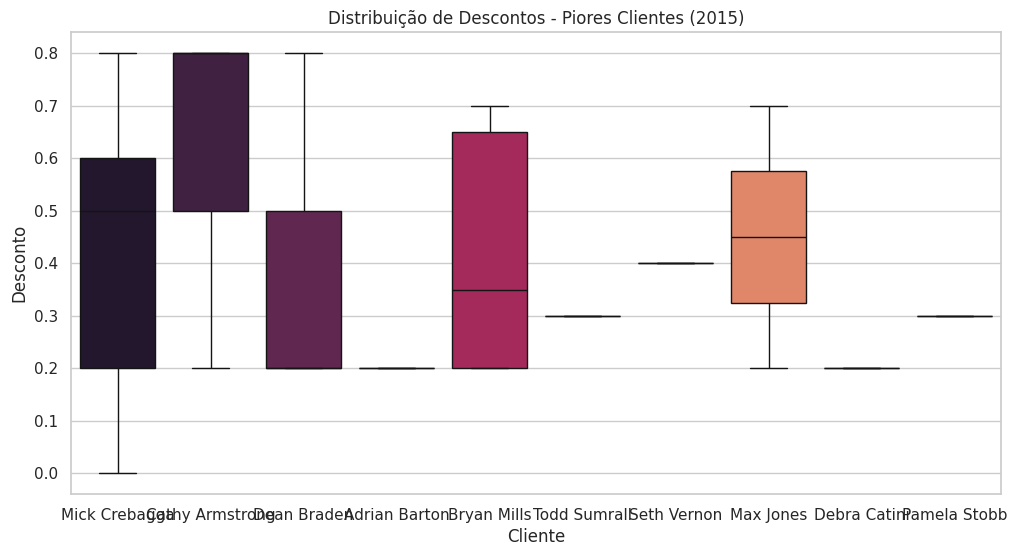

In [192]:
#. Plotando um boxplot para verificar a distribuição dos descontos que cada cliente recebeu

plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2015.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2015.sort_values().index, palette='rocket', showfliers=False)

plt.title('Distribuição de Descontos - Piores Clientes (2015)')
plt.xlabel('Cliente')
plt.ylabel('Desconto')

plt.show()

- Podemos ver que a maioria dos descontos que os clientes receberam está abaixo do 50%. Então, podemos imaginar o que o problema seja o tipo de compra que está sendo realizada.

In [193]:
#. Verificando quantas compras o pior cliente fez em cada categoria

df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')]['Category'].value_counts()

,count
Category,
Furniture,4
Office Supplies,4


- Podemos ver que o pior cliente realizou metade de suas compras em uma categoria que é rentável, juntamente com altos valores de desconto, resulta em prejuízo

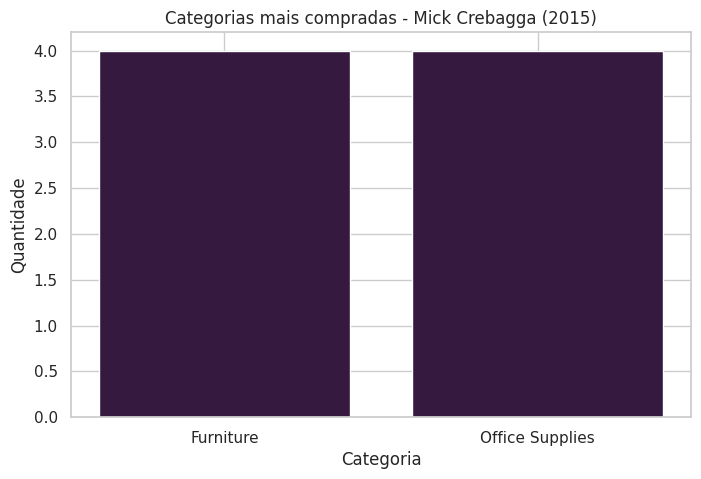

In [194]:
plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')]['Category'].value_counts().index, df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')]['Category'].value_counts().values)

plt.title('Categorias mais compradas - Mick Crebagga (2015)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.show()

In [196]:
df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,-55.7394
Office Supplies,-17.3024


- Analisando o lucro/prejuízo gerado pelo pior cliente podemos ver que, ele comprou de uma categoria que já não tem tanto valor agregado e msm assim realizou essas compras com muito desconto. Assim gerando prejuízo para a empresa.

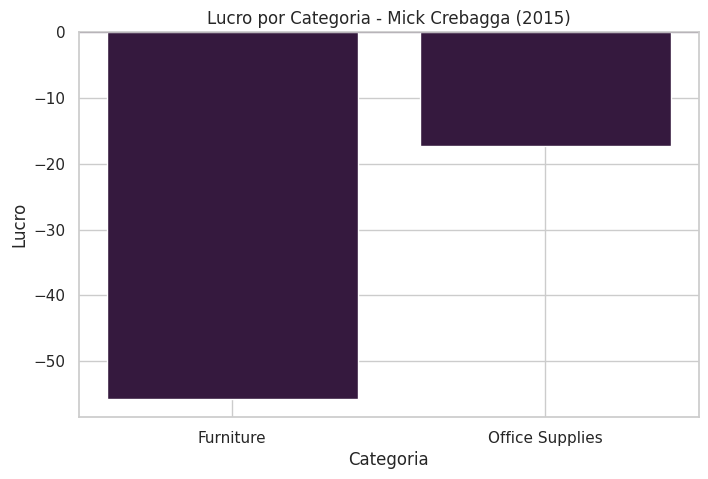

In [197]:
#. Plotando o lucro/Prejuízo que esse cliente produziu em suas compras

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Profit'].sum().index, df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Profit'].sum().values)

plt.title('Lucro por Categoria - Mick Crebagga (2015)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

In [198]:
#. Verificando a média de descontos que o cliente recebeu em cada categoria comprada.

df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Discount'].mean()

,Discount
Category,
Furniture,0.55
Office Supplies,0.30


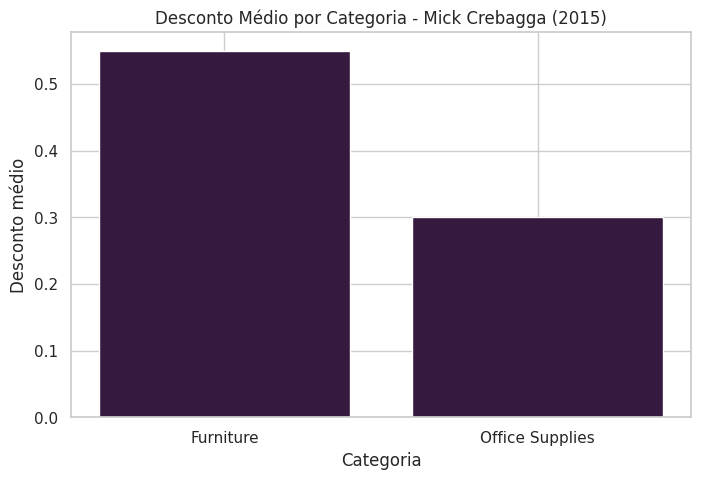

In [199]:
#. Plotando a média de desconto que o cliente recebeu em cada categoria.

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Discount'].mean().index, df_clean[(df_clean['Year'] == 2015) & (df_clean['Customer_Name'] == 'Mick Crebagga')].groupby('Category')['Discount'].mean().values)

plt.title('Desconto Médio por Categoria - Mick Crebagga (2015)')
plt.xlabel('Categoria')
plt.ylabel('Desconto médio')

plt.show()

- Aqui podemos concluir que o problema foi o alto valor de descontos em uma categoria que já não tinha valor agregado.

### Análise dos 10 Piores Clientes de 2016

In [200]:
#. Filtrando os 10 clientes que mais dão Prejuízo no ano de 2016

rentabilidade_clientes_2016 = df_clean[df_clean['Year'] == 2016].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)
print(rentabilidade_clientes_2016)

Customer_Name
Joe Elijah       -47.4713
Michael Paige    -45.4812
Justin Hirsh     -39.9118
Tanja Norvell    -38.2545
Tom Prescott     -38.2206
John Lucas       -37.9432
Troy Blackwell   -36.9544
Nick Zandusky    -36.2444
Duane Benoit     -35.2152
Adrian Hane      -35.1139
Name: Profit, dtype: float64


- Podemos ver que o pior cliente, nesse ano, foi Joe Elijah, com uma diferença pequena em relação ao segundo colocado.

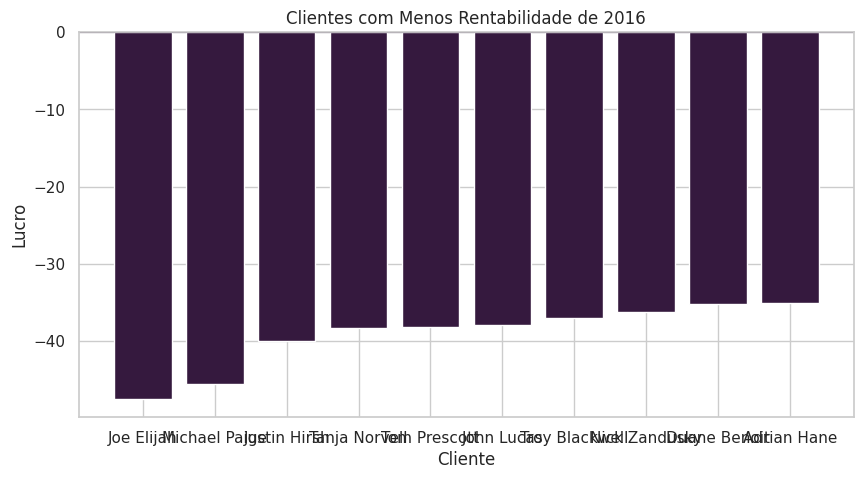

In [201]:
#. Plotando um gráfico de barras para demonstrar o prejuízo de cada Cliente

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2016.index, rentabilidade_clientes_2016.values)

plt.title('Clientes com Menos Rentabilidade de 2016')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

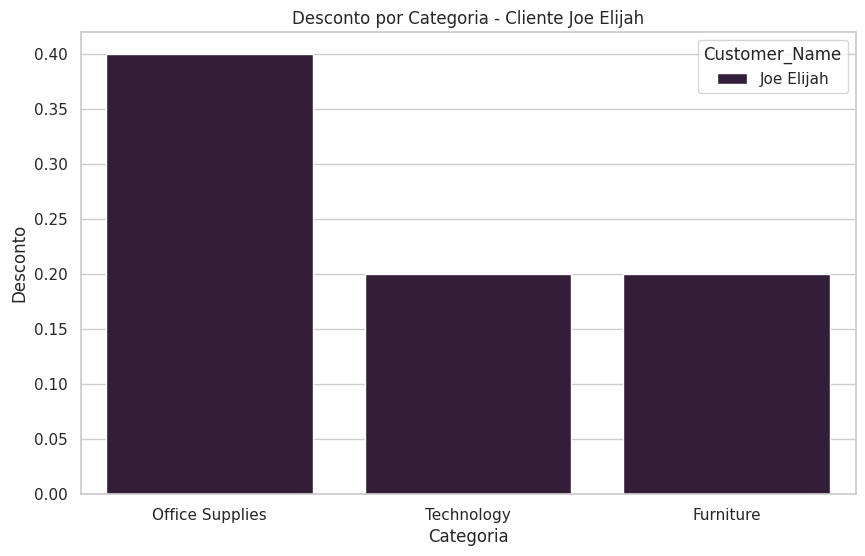

In [222]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Joe Elijah'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Joe Elijah')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [202]:
#. Verificando a quantidade de descontos altos que cada cliente recebeu

df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2016.index)) & (df_clean['Discount'] > 0.5)]['Customer_Name'].value_counts()

,count
Customer_Name,
Joe Elijah,4
John Lucas,2
Nick Zandusky,2
Michael Paige,2
Tom Prescott,2
Tanja Norvell,1
Adrian Hane,1


- Assim como no ano anterior, esse também não foi aplicado uma grande quantidade de altos descontos para os clientes. Possivelmente, o prejuízo foi causada por categorias rentáveis, mesmo com descontos baixos.

/tmp/ipykernel_12466/2786878502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2016.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2016.sort_values().index, palette='rocket', showfliers=False)


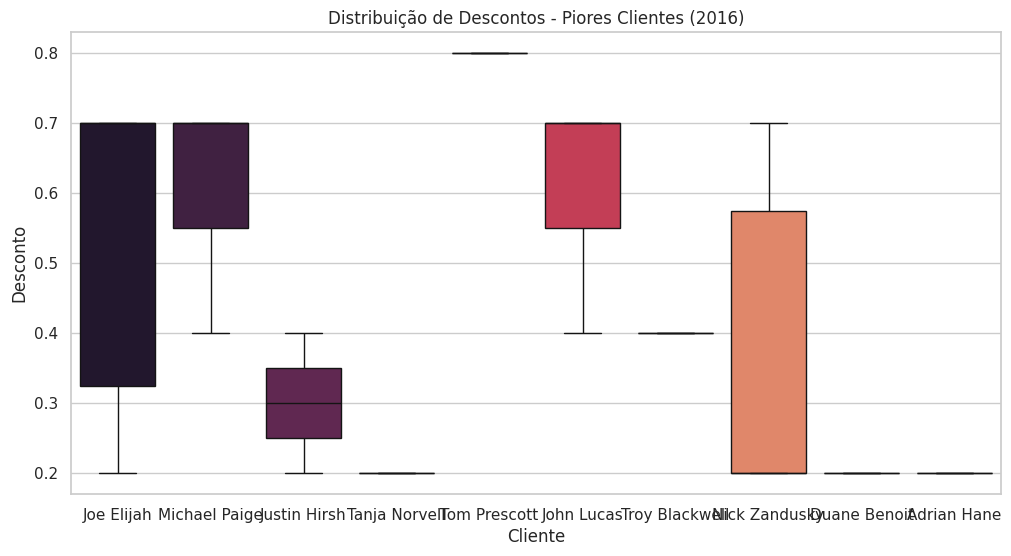

In [203]:
#. Plotando um boxplot para verificar a distribuição dos descontos que cada cliente recebeu

plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2016.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2016.sort_values().index, palette='rocket', showfliers=False)

plt.title('Distribuição de Descontos - Piores Clientes (2016)')
plt.xlabel('Cliente')
plt.ylabel('Desconto')

plt.show()

- Podemos ver que, mesmo recebendo pouco desconto, o pior cliente recebeu um desconto muito alto, 70%, e dependendo da compra que esse desconto foi aplicado pode causar um impacto muito grande na rentabilidade desse cliente.

In [204]:
#. Verificando quantas compras o pior cliente fez em cada categoria

df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')]['Category'].value_counts()

,count
Category,
Office Supplies,6


- Podemos ver que os descontos foram aplicados a uma categoria muito rentavel e como sabemos que o cliente recebeu descontos altos, essa junção gera prejuízo

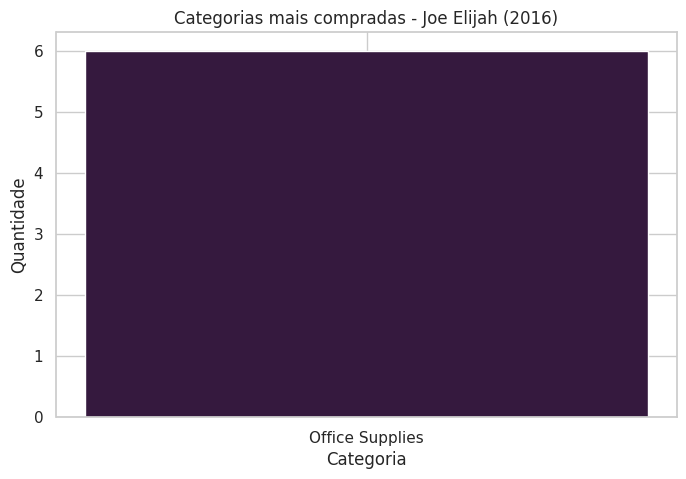

In [205]:
plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')]['Category'].value_counts().index, df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')]['Category'].value_counts().values)

plt.title('Categorias mais compradas - Joe Elijah (2016)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.show()

In [206]:
df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Profit'].sum()

,Profit
Category,
Office Supplies,-47.4713


- Como esperavamos, o prejuízo alto provém de uma categoria de alto valor também.

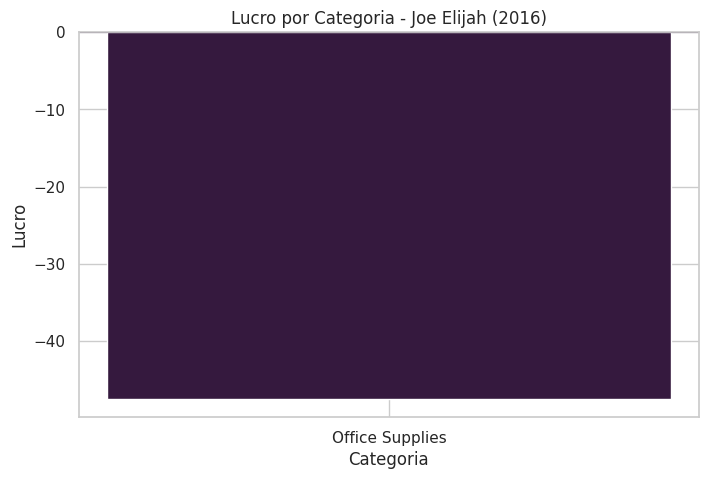

In [207]:
#. Plotando o lucro/Prejuízo que esse cliente produziu em suas compras

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Profit'].sum().index, df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Profit'].sum().values)

plt.title('Lucro por Categoria - Joe Elijah (2016)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

In [208]:
#. Verificando a média de descontos que o cliente recebeu em cada categoria comprada.

df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Discount'].mean()

,Discount
Category,
Office Supplies,0.533333


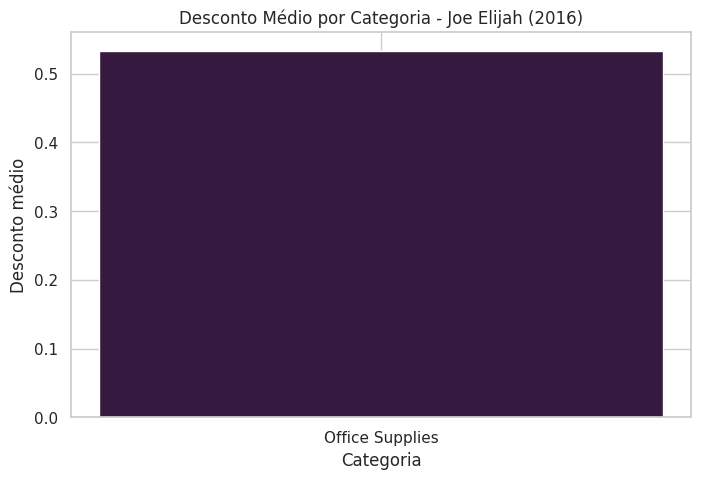

In [209]:
#. Plotando a média de desconto que o cliente recebeu em cada categoria.

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Discount'].mean().index, df_clean[(df_clean['Year'] == 2016) & (df_clean['Customer_Name'] == 'Joe Elijah')].groupby('Category')['Discount'].mean().values)

plt.title('Desconto Médio por Categoria - Joe Elijah (2016)')
plt.xlabel('Categoria')
plt.ylabel('Desconto médio')

plt.show()

- Aqui podemos ver que grandes descontos aplicados a uma categoria rentável resulta em um prejuízo

### Análise dos 10 Piores Clientes de 2017

In [210]:
#. Filtrando os 10 clientes que mais dão Prejuízo no ano de 2017

rentabilidade_clientes_2017 = df_clean[df_clean['Year'] == 2017].groupby('Customer_Name')['Profit'].sum().sort_values(ascending=True).head(10)
print(rentabilidade_clientes_2017)

Customer_Name
Janet Martin        -45.8694
Pamela Stobb        -44.4331
Erica Smith         -44.3610
Steve Chapman       -38.8212
Ryan Akin           -37.3656
Barry Französisch   -34.6329
John Huston         -34.2405
Anna Chung          -32.3388
Alan Shonely        -31.9160
Brad Eason          -30.8564
Name: Profit, dtype: float64


- Aqui podemos ver que o Janet Martin, foi o que mais deu prejuízo para empresa. Além disso, podemos ver que a maioria está bem próxima.

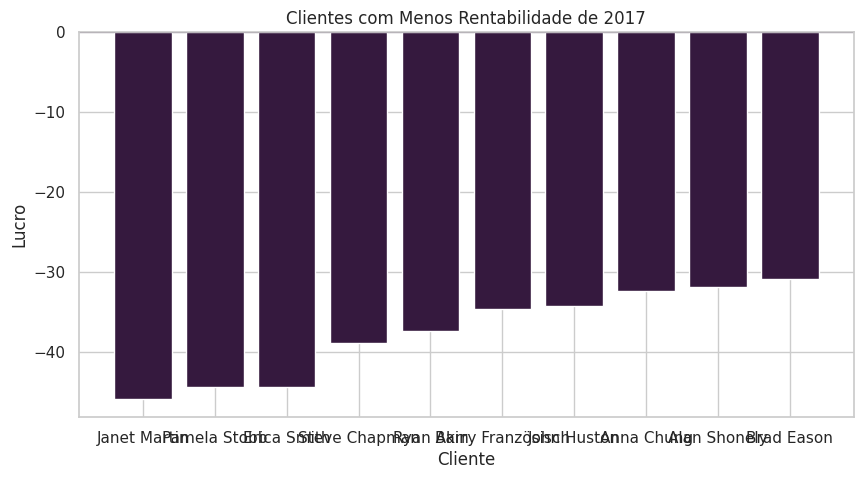

In [211]:
#. Plotando um gráfico de barras para demonstrar o prejuízo de cada Cliente

plt.figure(figsize=(10,5))

plt.bar(rentabilidade_clientes_2017.index, rentabilidade_clientes_2017.values)

plt.title('Clientes com Menos Rentabilidade de 2017')
plt.xlabel('Cliente')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

Mais uma vez, o que podemos analisar para justificar esse alto prejuízo é o tamanho do desconto e a categoria a qual ele foi aplicado.

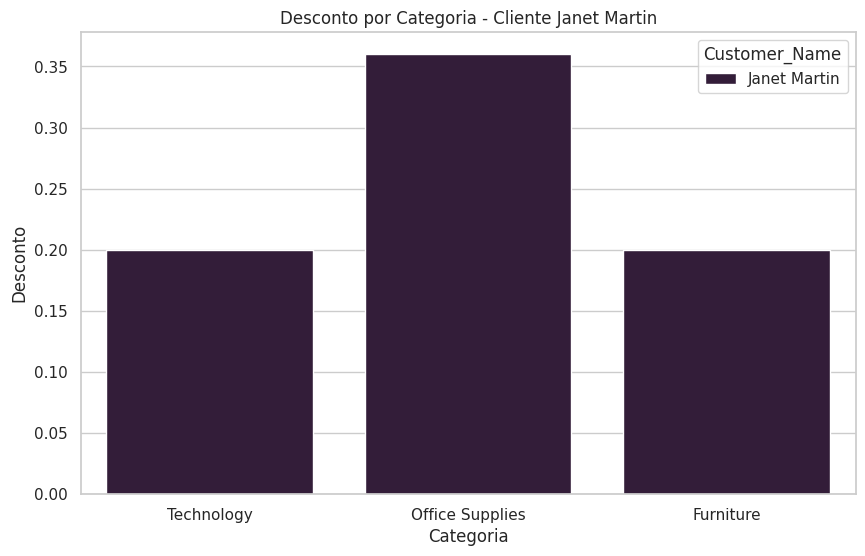

In [221]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean[df_clean['Customer_Name'] == 'Janet Martin'], x='Category', y='Discount', hue='Customer_Name', estimator='mean', errorbar=None)

plt.title('Desconto por Categoria - Cliente Janet Martin')
plt.xlabel('Categoria')
plt.ylabel('Desconto')

plt.show()

In [212]:
#. Verificando a quantidade de descontos altos que cada cliente recebeu

df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2017.index)) & (df_clean['Discount'] > 0.5)]['Customer_Name'].value_counts()

,count
Customer_Name,
Pamela Stobb,3
Janet Martin,3
Alan Shonely,1
Barry Französisch,1
Ryan Akin,1
Steve Chapman,1
Brad Eason,1


- Podemos ver que nesse ano não foram aplicados tantos descontos altos para os clientes. O que podemos imaginar inicialmente, é que esses descontos foram aplicados a categorias que são muito rentáveis, assim gerando prejuízo

/tmp/ipykernel_12466/1279025461.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2017.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2017.sort_values().index, palette='rocket', showfliers=False)


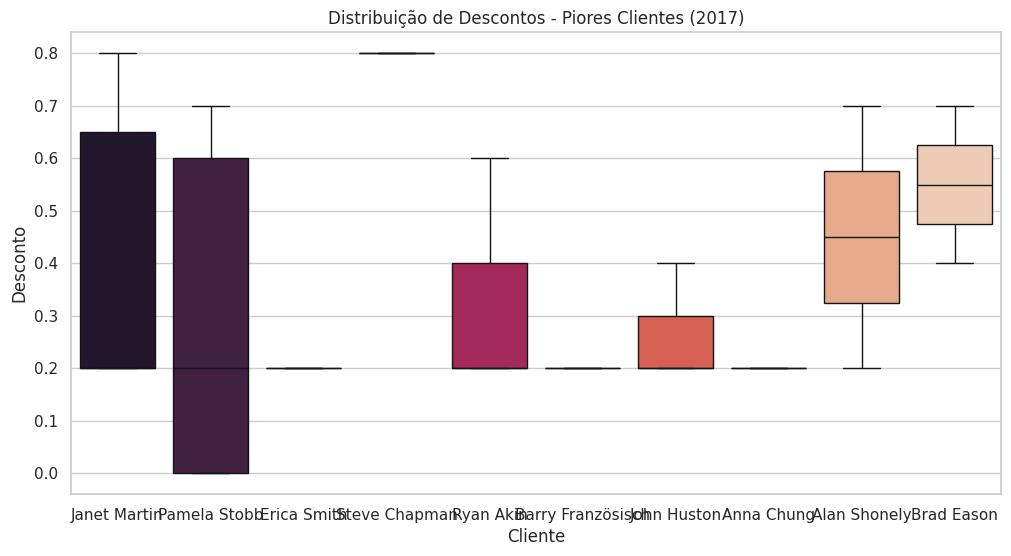

In [213]:
#. Plotando um boxplot para verificar a distribuição dos descontos que cada cliente recebeu

plt.figure(figsize=(12,6))

sns.boxplot(data=df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'].isin(rentabilidade_clientes_2017.index))], x='Customer_Name', y='Discount', order = rentabilidade_clientes_2017.sort_values().index, palette='rocket', showfliers=False)

plt.title('Distribuição de Descontos - Piores Clientes (2017)')
plt.xlabel('Cliente')
plt.ylabel('Desconto')

plt.show()

- Aqui podemos ver que a maioria dos descontos estão acima de 20%, o que dependendo da categoria pode causar um grande impacto.

In [214]:
#. Verificando quantas compras o pior cliente fez em cada categoria

df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')]['Category'].value_counts()

,count
Category,
Office Supplies,7
Technology,2
Furniture,1


- Aqui vemos que o cliente realizou a maioria das suas compras em categorias Rentáveis

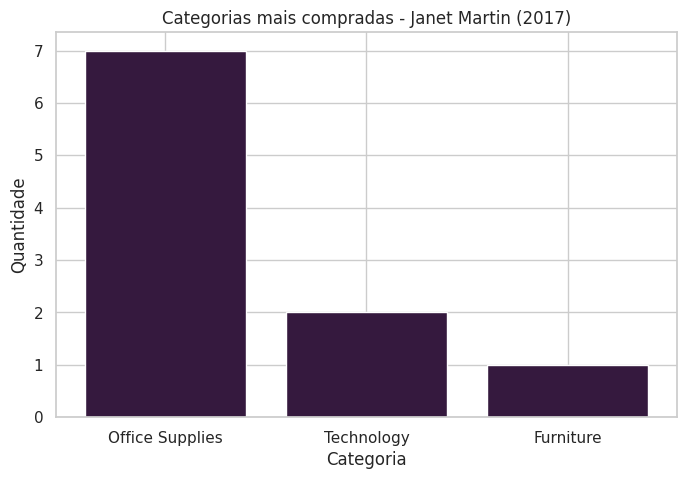

In [215]:
plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')]['Category'].value_counts().index, df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')]['Category'].value_counts().values)

plt.title('Categorias mais compradas - Janet Martin (2017)')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')

plt.show()

In [216]:
df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,15.5904
Office Supplies,-81.1608
Technology,19.7010


- Aqui confirmamos que o prejuízo foi resultado de uma compra de uma categoria altamente rentável acrescido do fator de desconto.

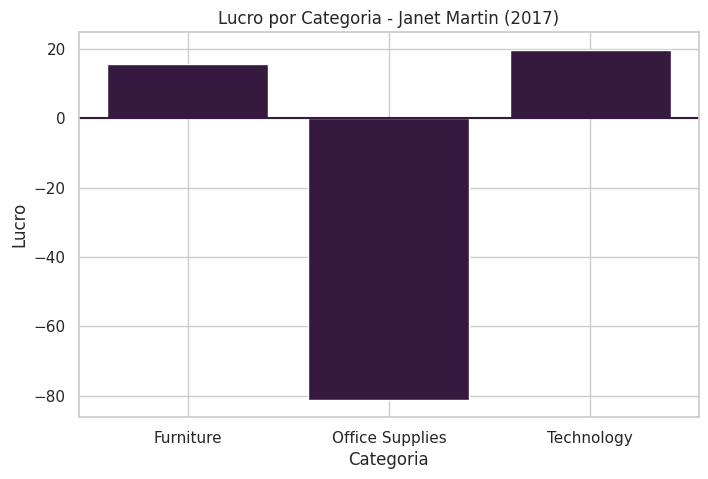

In [217]:
#. Plotando o lucro/Prejuízo que esse cliente produziu em suas compras

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Profit'].sum().index, df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Profit'].sum().values)

plt.title('Lucro por Categoria - Janet Martin (2017)')
plt.xlabel('Categoria')
plt.ylabel('Lucro')

plt.axhline(0)

plt.show()

In [218]:
#. Verificando a média de descontos que o cliente recebeu em cada categoria comprada.

df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Discount'].mean()

,Discount
Category,
Furniture,0.200000
Office Supplies,0.457143
Technology,0.200000


- Aqui vemos que o cliente recebeu um desconto de 50% em uma categoria altamente rentável, o que é o suficiente para resultar em um prejuízo.

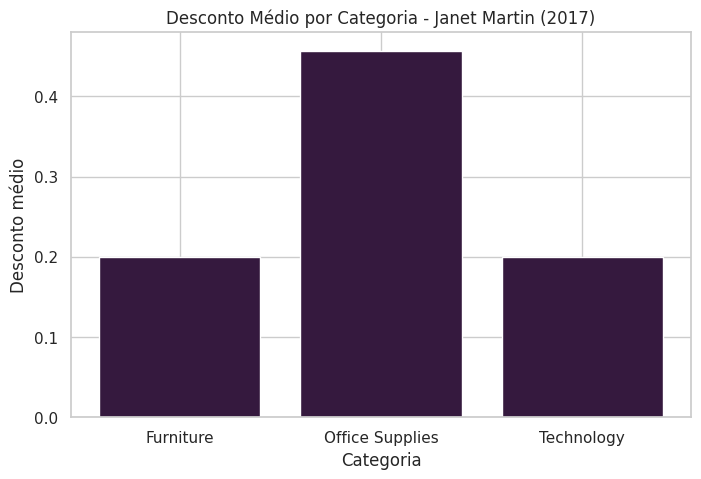

In [219]:
#. Plotando a média de desconto que o cliente recebeu em cada categoria.

plt.figure(figsize=(8,5))

plt.bar(df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Discount'].mean().index, df_clean[(df_clean['Year'] == 2017) & (df_clean['Customer_Name'] == 'Janet Martin')].groupby('Category')['Discount'].mean().values)

plt.title('Desconto Médio por Categoria - Janet Martin (2017)')
plt.xlabel('Categoria')
plt.ylabel('Desconto médio')

plt.show()

- Aqui confirmamos mais uma vez que um desconto alto, aplicado tanto em uma categoria não tão rentável quanto em uma categoria rentável gera prejuízo.